# Part 3b — Feature experiments on top of part_3

Test fire feature-udvidelser hver for sig oven på part_3's slutmodel:

- **A:** Hour-of-day dummies × workday (erstatter sin/cos for time)
- **B:** Hour × season interaktioner
- **C:** Day-of-week dummies
- **D:** Hour × temperatur og hour × precipitation

Baseline til sammenligning er part_3's forward-selected model (val RMSE ≈ 124).


### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from sklearn.linear_model import *

### Loading Data

In [2]:
df_bike_counts = pd.read_csv('bike_project_data/bike_counts.csv', sep=',', names=["datetime","station","latitude","longitude","bike_count"], header=0)
df_holidays = pd.read_csv('bike_project_data/danish_holidays.csv', sep=',', names=["date","holiday"], header=0)
df_stations = pd.read_csv('bike_project_data/stations.csv', sep=',', names=["station","latitude","longitude","daily_avg_2021"], header=0)
df_weather = pd.read_csv('bike_project_data/weather_copenhagen.csv', sep=',', names=["datetime","temperature_C","wind_speed_ms","precipitation_mm"], header=0)

### Splitting Data - Langebro Station

In [3]:
Station = "Langebro"

df_bike_counts["datetime"] = pd.to_datetime(df_bike_counts["datetime"])
df_weather["datetime"] = pd.to_datetime(df_weather["datetime"])
df_holidays["datetime"] = pd.to_datetime(df_holidays["date"])
df_holidays["holiday"] = True

df_merged = pd.merge(df_bike_counts, df_weather, on="datetime", how="left")

df_merged["date"] = df_merged["datetime"].dt.date
df_holidays["date"] = df_holidays["datetime"].dt.date

df_merged = pd.merge(df_merged, df_holidays[["date", "holiday"]], on="date", how="left")
df_merged["holiday"] = df_merged["holiday"].fillna(False)

df_merged.ffill(inplace=True)

df_training   = df_merged[(df_merged["datetime"].dt.year == 2021) & (df_merged["station"] == Station)].copy()
df_validating = df_merged[(df_merged["datetime"].dt.year == 2022) & (df_merged["station"] == Station)].copy()
df_testing    = df_merged[(df_merged["datetime"].dt.year == 2023) & (df_merged["station"] == Station)].copy()

/var/folders/pt/srr73kjx1pdbnpwylcyp844r0000gn/T/ipykernel_9100/2438475919.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged["holiday"] = df_merged["holiday"].fillna(False)


### Helper functions
Same style as part_2 — with two fixes:
- `ridge_reg` now uses `X.shape[1]` (number of features), not `X.shape[0]`.
- `calculate_RMSE` uses **mean**, so train / val / test errors are comparable.

In [4]:
def linear_reg(X, y):
    return np.linalg.solve(X.T @ X, X.T @ y)

def ridge_reg(X, y, lam):
    return np.linalg.solve(X.T @ X + lam * np.eye(X.shape[1]), X.T @ y)

def calculate_RMSE(X, w, y_true):
    y_pred = np.maximum((X @ w).flatten(), 0)
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def standardize_train(X):
    # leave intercept (col 0) untouched
    mu = X[:, 1:].mean(axis=0)
    sigma = X[:, 1:].std(axis=0)
    sigma = np.where(sigma == 0, 1.0, sigma)
    X_std = X.copy().astype(float)
    X_std[:, 1:] = (X[:, 1:] - mu) / sigma
    return X_std, mu, sigma

def standardize_apply(X, mu, sigma):
    X_std = X.copy().astype(float)
    X_std[:, 1:] = (X[:, 1:] - mu) / sigma
    return X_std

### Feature engineering — generate all candidates
Extends `build_system` from part_2:
- hour harmonics k=1..6 (higher k = sharper peaks for commute)
- dayofyear cycle, first AND second harmonic (uses `dayofyear`, fixes the `dt.day / 365` bug)
- day-of-week cycle, weekend / holiday / workday indicators
- quadratic temp / wind, log(1+precip), is_raining
- hour × workday for **all** harmonics (commute spikes only on workdays)
- temp / precip / wind × workday (commuters react to weather differently than weekend cyclists)

In [5]:
def add_features(df):
    df = df.copy()
    h   = df["datetime"].dt.hour
    doy = df["datetime"].dt.dayofyear
    dow = df["datetime"].dt.dayofweek

    # cyclical hour at multiple harmonics — k up to 6 captures sharp commute spikes
    for k in [1, 2, 3, 4, 5, 6]:
        df[f"h_sin{k}"] = np.sin(2 * np.pi * k * h / 24)
        df[f"h_cos{k}"] = np.cos(2 * np.pi * k * h / 24)

    # seasonal cycle — first and second harmonic of dayofyear
    df["d_sin1"] = np.sin(2 * np.pi * doy / 365)
    df["d_cos1"] = np.cos(2 * np.pi * doy / 365)
    df["d_sin2"] = np.sin(4 * np.pi * doy / 365)
    df["d_cos2"] = np.cos(4 * np.pi * doy / 365)

    # day of week (cyclical)
    df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    df["dow_cos"] = np.cos(2 * np.pi * dow / 7)

    # calendar indicators
    df["is_weekend"] = (dow >= 5).astype(float)
    df["is_holiday"] = df["holiday"].astype(float)
    df["is_workday"] = ((1 - df["is_weekend"]) * (1 - df["is_holiday"])).astype(float)

    # weather
    df["temp"]       = df["temperature_C"]
    df["temp_sq"]    = df["temperature_C"] ** 2
    df["wind"]       = df["wind_speed_ms"]
    df["wind_sq"]    = df["wind_speed_ms"] ** 2
    df["precip"]     = df["precipitation_mm"]
    df["log_precip"] = np.log1p(df["precipitation_mm"])
    df["is_raining"] = (df["precipitation_mm"] > 0.1).astype(float)

    # commute interactions: hour × workday for ALL harmonics
    for k in [1, 2, 3, 4, 5, 6]:
        df[f"h_sin{k}_wd"] = df[f"h_sin{k}"] * df["is_workday"]
        df[f"h_cos{k}_wd"] = df[f"h_cos{k}"] * df["is_workday"]

    # weather × workday interactions
    df["temp_wd"]   = df["temp"] * df["is_workday"]
    df["precip_wd"] = df["precip"] * df["is_workday"]
    df["wind_wd"]   = df["wind"] * df["is_workday"]

    return df


df_training   = add_features(df_training)
df_validating = add_features(df_validating)
df_testing    = add_features(df_testing)


def build_X(df, feature_names):
    n = df.shape[0]
    cols = [np.ones(n)]
    for name in feature_names:
        cols.append(df[name].values.astype(float))
    return np.column_stack(cols)


y_tr = df_training["bike_count"].values
y_va = df_validating["bike_count"].values
y_te = df_testing["bike_count"].values


### Helper — residual diagnostics


In [6]:
def plot_residuals(df_, residuals, title):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes[0,0].scatter(df_["datetime"].dt.hour,        residuals, alpha=0.2, s=4)
    axes[0,0].set_xlabel("hour");           axes[0,0].set_ylabel("residual")
    axes[0,1].scatter(df_["datetime"].dt.dayofweek,   residuals, alpha=0.2, s=4)
    axes[0,1].set_xlabel("day of week")
    axes[0,2].scatter(df_["datetime"].dt.dayofyear,   residuals, alpha=0.2, s=4)
    axes[0,2].set_xlabel("day of year")
    axes[1,0].scatter(df_["temperature_C"],           residuals, alpha=0.2, s=4)
    axes[1,0].set_xlabel("temperature (C)"); axes[1,0].set_ylabel("residual")
    axes[1,1].scatter(df_["wind_speed_ms"],           residuals, alpha=0.2, s=4)
    axes[1,1].set_xlabel("wind (m/s)")
    axes[1,2].scatter(df_["precipitation_mm"],        residuals, alpha=0.2, s=4)
    axes[1,2].set_xlabel("precipitation (mm)")
    for ax in axes.flat:
        ax.axhline(0, color="red", linewidth=0.8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


### Feature groups and evaluator (genbrug fra part_3)


In [7]:
feature_groups = {
    "hour_24":       ["h_sin1", "h_cos1"],
    "hour_12":       ["h_sin2", "h_cos2"],
    "hour_8":        ["h_sin3", "h_cos3"],
    "hour_6":        ["h_sin4", "h_cos4"],
    "hour_4_8":      ["h_sin5", "h_cos5"],
    "hour_4":        ["h_sin6", "h_cos6"],
    "dayofyear_1":   ["d_sin1", "d_cos1"],
    "dayofyear_2":   ["d_sin2", "d_cos2"],
    "dayofweek":     ["dow_sin", "dow_cos"],
    "is_weekend":    ["is_weekend"],
    "is_holiday":    ["is_holiday"],
    "is_workday":    ["is_workday"],
    "temp":          ["temp"],
    "temp_sq":       ["temp_sq"],
    "wind":          ["wind"],
    "wind_sq":       ["wind_sq"],
    "precip":        ["precip"],
    "log_precip":    ["log_precip"],
    "is_raining":    ["is_raining"],
    "hour24_x_wd":   ["h_sin1_wd", "h_cos1_wd"],
    "hour12_x_wd":   ["h_sin2_wd", "h_cos2_wd"],
    "hour8_x_wd":    ["h_sin3_wd", "h_cos3_wd"],
    "hour6_x_wd":    ["h_sin4_wd", "h_cos4_wd"],
    "hour4_8_x_wd":  ["h_sin5_wd", "h_cos5_wd"],
    "hour4_x_wd":    ["h_sin6_wd", "h_cos6_wd"],
    "temp_x_wd":     ["temp_wd"],
    "precip_x_wd":   ["precip_wd"],
    "wind_x_wd":     ["wind_wd"],
}

y_tr = df_training["bike_count"].values
y_va = df_validating["bike_count"].values
y_te = df_testing["bike_count"].values

def eval_features(feat_names, lam=0.0):
    X_tr = build_X(df_training,   feat_names)
    X_va = build_X(df_validating, feat_names)
    X_tr_s, mu, sigma = standardize_train(X_tr)
    X_va_s = standardize_apply(X_va, mu, sigma)
    try:
        w = ridge_reg(X_tr_s, y_tr, lam)
    except np.linalg.LinAlgError:
        return np.inf
    return calculate_RMSE(X_va_s, w, y_va)


## 1. Reference-baseline — gendan part_3's slutmodel

Kør forward selection som i part_3. Output: `selected_features_p3` og baseline RMSE'er der bliver målestokken for alle eksperimenter.


In [8]:
def forward_select(groups_dict, lam=0.0, verbose=False):
    selected_groups, selected_features = [], []
    remaining = list(groups_dict.keys())
    best_rmse = eval_features([], lam=lam)
    history = [("(intercept only)", best_rmse)]
    while remaining:
        best_g, best_g_rmse = None, best_rmse
        for g in remaining:
            trial = selected_features + groups_dict[g]
            rmse = eval_features(trial, lam=lam)
            if rmse < best_g_rmse:
                best_g_rmse, best_g = rmse, g
        if best_g is None:
            break
        selected_groups.append(best_g)
        selected_features += groups_dict[best_g]
        remaining.remove(best_g)
        best_rmse = best_g_rmse
        history.append((best_g, best_rmse))
    if verbose:
        for g, r in history:
            print(f"{g:25s}  val RMSE = {r:.2f}")
    return selected_groups, selected_features, history

selected_groups_p3, selected_features_p3, history_p3 = forward_select(
    feature_groups, lam=0.0, verbose=True)
print(f"\nSelected groups (part_3): {selected_groups_p3}")


(intercept only)           val RMSE = 259.81
temp_x_wd                  val RMSE = 217.31
hour_24                    val RMSE = 191.17
hour_8                     val RMSE = 170.57
hour12_x_wd                val RMSE = 156.59
dayofyear_1                val RMSE = 146.37
hour_4_8                   val RMSE = 136.78
hour4_x_wd                 val RMSE = 133.15
hour24_x_wd                val RMSE = 130.46
hour_12                    val RMSE = 129.29
hour8_x_wd                 val RMSE = 127.92
wind                       val RMSE = 126.78
precip                     val RMSE = 126.10
hour4_8_x_wd               val RMSE = 125.62
hour_4                     val RMSE = 125.09
temp                       val RMSE = 124.77
hour6_x_wd                 val RMSE = 124.54
dayofyear_2                val RMSE = 124.50
hour_6                     val RMSE = 124.48
precip_x_wd                val RMSE = 124.46
log_precip                 val RMSE = 124.46
wind_sq                    val RMSE = 124.46

Selected 

In [9]:
# Train reference model and compute train/val/test RMSE
X_tr = build_X(df_training,   selected_features_p3)
X_va = build_X(df_validating, selected_features_p3)
X_te = build_X(df_testing,    selected_features_p3)
X_tr_s, mu_ref, sigma_ref = standardize_train(X_tr)
X_va_s = standardize_apply(X_va, mu_ref, sigma_ref)
X_te_s = standardize_apply(X_te, mu_ref, sigma_ref)

w_ref = ridge_reg(X_tr_s, y_tr, 0.0)
ref_train = calculate_RMSE(X_tr_s, w_ref, y_tr)
ref_val   = calculate_RMSE(X_va_s, w_ref, y_va)
ref_test  = calculate_RMSE(X_te_s, w_ref, y_te)
print(f"Reference (part_3)  train={ref_train:.2f}  val={ref_val:.2f}  test={ref_test:.2f}")

baseline_residuals_va = y_va - np.maximum((X_va_s @ w_ref).flatten(), 0)


Reference (part_3)  train=114.12  val=124.46  test=124.18


## 2. Diagnostik — residualstruktur ved time 8 og 17

Plot baseline-residualer ved problematiske timer mod måned, day-of-week, temp, og precip. Hvis residualerne stadig korrelerer med disse, mangler vi en interaktion.


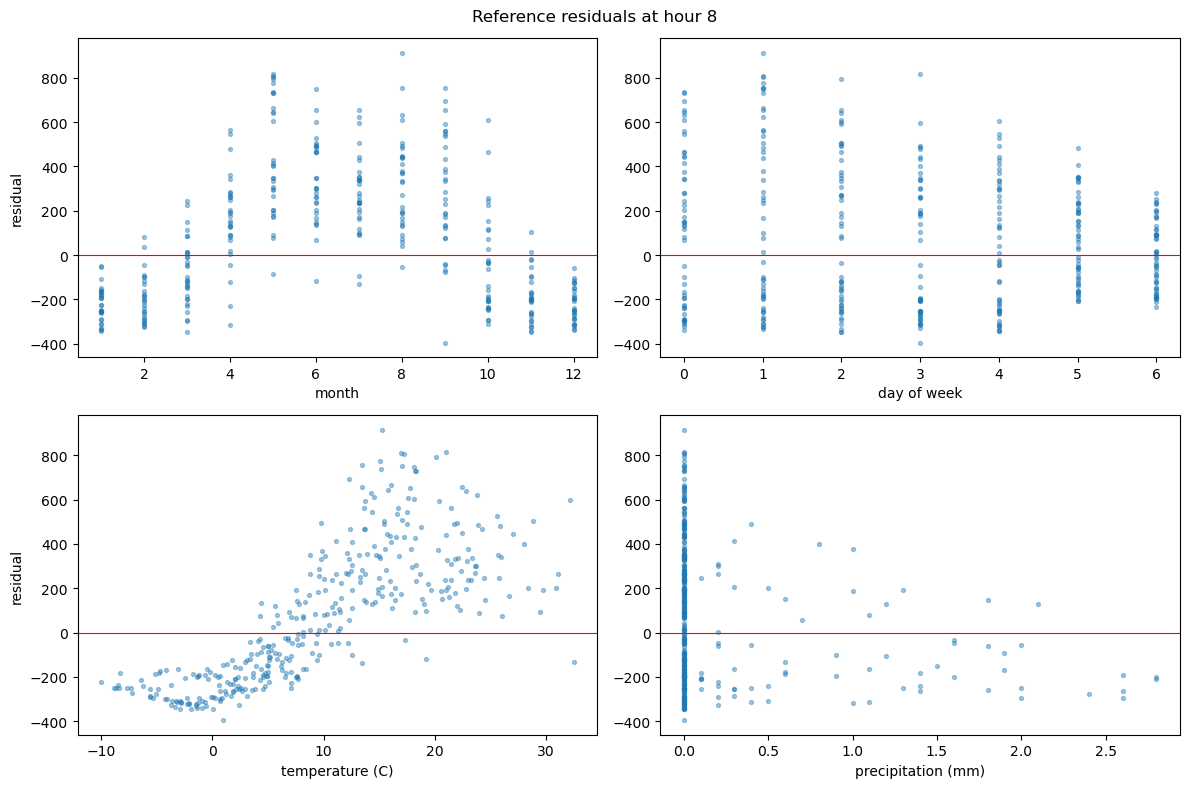

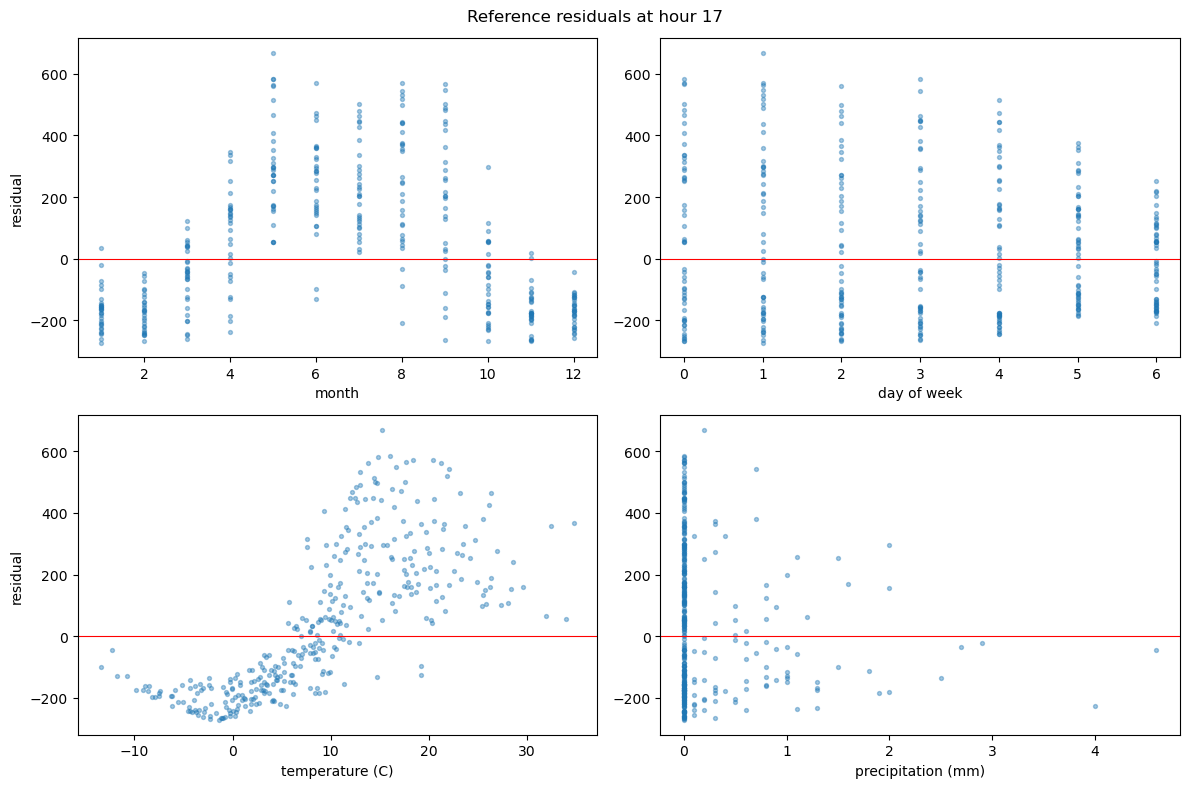

In [10]:
for target_hour in [8, 17]:
    mask = df_validating["datetime"].dt.hour == target_hour
    df_h = df_validating.loc[mask]
    resid_h = baseline_residuals_va[mask.values]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0,0].scatter(df_h["datetime"].dt.month,     resid_h, alpha=0.4, s=8)
    axes[0,0].set_xlabel("month");           axes[0,0].set_ylabel("residual")
    axes[0,1].scatter(df_h["datetime"].dt.dayofweek, resid_h, alpha=0.4, s=8)
    axes[0,1].set_xlabel("day of week")
    axes[1,0].scatter(df_h["temperature_C"],         resid_h, alpha=0.4, s=8)
    axes[1,0].set_xlabel("temperature (C)");  axes[1,0].set_ylabel("residual")
    axes[1,1].scatter(df_h["precipitation_mm"],      resid_h, alpha=0.4, s=8)
    axes[1,1].set_xlabel("precipitation (mm)")
    for ax in axes.flat:
        ax.axhline(0, color="red", linewidth=0.8)
    fig.suptitle(f"Reference residuals at hour {target_hour}")
    plt.tight_layout()
    plt.show()


## 3. Generer nye eksperimentelle features

Tilføj alle kandidater til de tre dataframes på én gang så hvert eksperiment kun skal vælge fra en liste.


In [11]:
def add_experimental_features(df):
    df = df.copy()
    h   = df["datetime"].dt.hour
    dow = df["datetime"].dt.dayofweek

    # A: hour-of-day dummies and dummy x workday (drop hour 0 as reference)
    for hh in range(1, 24):
        df[f"is_hour_{hh}"]    = (h == hh).astype(float)
        df[f"is_hour_{hh}_wd"] = df[f"is_hour_{hh}"] * df["is_workday"]

    # B: hour x season (k=1,2 with d=1,2)
    for k in [1, 2]:
        for s in [1, 2]:
            df[f"h_sin{k}_x_d_sin{s}"] = df[f"h_sin{k}"] * df[f"d_sin{s}"]
            df[f"h_sin{k}_x_d_cos{s}"] = df[f"h_sin{k}"] * df[f"d_cos{s}"]
            df[f"h_cos{k}_x_d_sin{s}"] = df[f"h_cos{k}"] * df[f"d_sin{s}"]
            df[f"h_cos{k}_x_d_cos{s}"] = df[f"h_cos{k}"] * df[f"d_cos{s}"]

    # C: day-of-week dummies (drop Monday=0 as reference)
    for d in range(1, 7):
        df[f"is_dow_{d}"] = (dow == d).astype(float)

    # D: hour x weather (k=1,2)
    for k in [1, 2]:
        df[f"h_sin{k}_x_temp"]   = df[f"h_sin{k}"] * df["temp"]
        df[f"h_cos{k}_x_temp"]   = df[f"h_cos{k}"] * df["temp"]
        df[f"h_sin{k}_x_precip"] = df[f"h_sin{k}"] * df["precip"]
        df[f"h_cos{k}_x_precip"] = df[f"h_cos{k}"] * df["precip"]

    return df

df_training   = add_experimental_features(df_training)
df_validating = add_experimental_features(df_validating)
df_testing    = add_experimental_features(df_testing)

# Convenience name lists
hour_dummy_feats     = [f"is_hour_{hh}"    for hh in range(1, 24)]
hour_dummy_wd_feats  = [f"is_hour_{hh}_wd" for hh in range(1, 24)]
hour_x_season_feats  = [f"h_{t}{k}_x_d_{u}{s}"
                        for k in [1,2] for s in [1,2]
                        for t in ["sin","cos"] for u in ["sin","cos"]]
dow_dummy_feats      = [f"is_dow_{d}" for d in range(1, 7)]
hour_x_temp_feats    = [f"h_{t}{k}_x_temp"   for k in [1,2] for t in ["sin","cos"]]
hour_x_precip_feats  = [f"h_{t}{k}_x_precip" for k in [1,2] for t in ["sin","cos"]]

n_new = (len(hour_dummy_feats) + len(hour_dummy_wd_feats) + len(hour_x_season_feats)
         + len(dow_dummy_feats) + len(hour_x_temp_feats) + len(hour_x_precip_feats))
print(f"Added {n_new} experimental features per dataframe")


Added 76 experimental features per dataframe


### Hjælpefunktion — træn og rapportér på et vilkårligt feature-sæt


In [12]:
def fit_and_score(feat_names, lam=0.0, label="model"):
    X_tr = build_X(df_training,   feat_names)
    X_va = build_X(df_validating, feat_names)
    X_te = build_X(df_testing,    feat_names)
    X_tr_s, mu, sigma = standardize_train(X_tr)
    X_va_s = standardize_apply(X_va, mu, sigma)
    X_te_s = standardize_apply(X_te, mu, sigma)
    w = ridge_reg(X_tr_s, y_tr, lam)
    tr = calculate_RMSE(X_tr_s, w, y_tr)
    va = calculate_RMSE(X_va_s, w, y_va)
    te = calculate_RMSE(X_te_s, w, y_te)
    print(f"{label:35s}  train={tr:.2f}  val={va:.2f}  test={te:.2f}  (n_feat={len(feat_names)})")
    resid = y_va - np.maximum((X_va_s @ w).flatten(), 0)
    return {"label": label, "train": tr, "val": va, "test": te,
            "w": w, "feats": feat_names, "resid_va": resid}


## 4. Eksperiment A — Hour-of-day dummies × workday

Erstat alle hour-harmoniske features (`h_sin*`, `h_cos*`, `h_sin*_wd`, `h_cos*_wd`) med 23 hour-dummies + 23 hour-dummies × workday = 46 features. Hour 0 er referencekategori.


In [13]:
hour_harm_feats    = [f for k in [1,2,3,4,5,6] for f in [f"h_sin{k}", f"h_cos{k}"]]
hour_harm_wd_feats = [f for k in [1,2,3,4,5,6] for f in [f"h_sin{k}_wd", f"h_cos{k}_wd"]]
to_drop = set(hour_harm_feats + hour_harm_wd_feats)

feats_A = [f for f in selected_features_p3 if f not in to_drop] \
          + hour_dummy_feats + hour_dummy_wd_feats

res_A = fit_and_score(feats_A, lam=0.0, label="A: hour dummies x wd")


A: hour dummies x wd                 train=112.51  val=123.04  test=123.01  (n_feat=57)


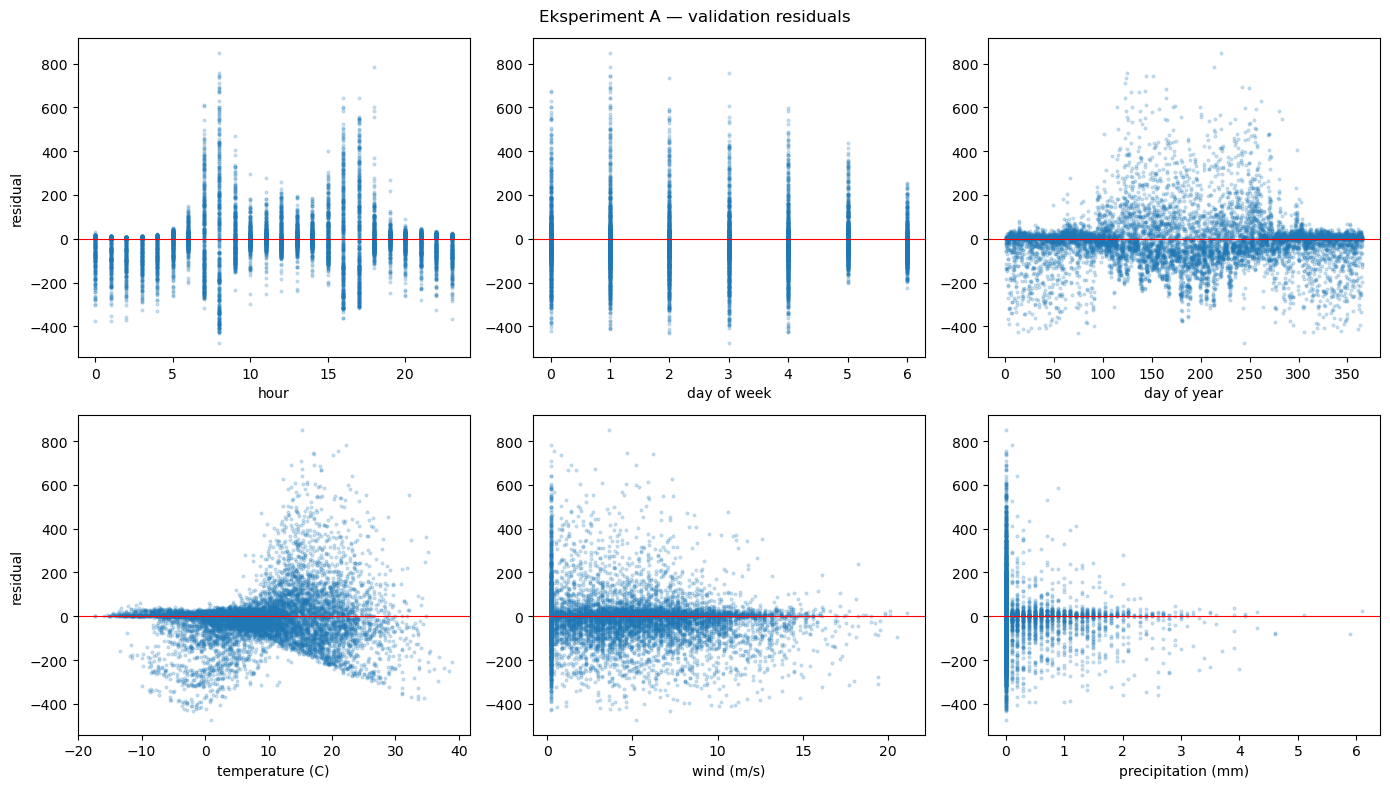

In [14]:
plot_residuals(df_validating, res_A["resid_va"], "Eksperiment A — validation residuals")


## 5. Eksperiment B — Hour × season interaktioner

Tilføj 16 produkter af hour-harmoniske (k=1,2) med dayofyear-harmoniske (s=1,2) til part_3's selected features.


In [15]:
feats_B = list(selected_features_p3) + hour_x_season_feats
res_B = fit_and_score(feats_B, lam=0.0, label="B: hour x season")


B: hour x season                     train=95.25  val=103.92  test=103.64  (n_feat=51)


## 6. Eksperiment C — Day-of-week dummies

Tilføj 6 binære dow-dummies (Monday=0 som reference). Beholder `is_workday` for at bevare hour×wd-interaktionerne; dummies fanger hovedeffekt-variation mellem ugedage (fx fredag ≠ tirsdag).


In [16]:
feats_C = list(selected_features_p3) + dow_dummy_feats
res_C = fit_and_score(feats_C, lam=0.0, label="C: dow dummies")


C: dow dummies                       train=113.86  val=124.42  test=124.43  (n_feat=41)


## 7. Eksperiment D — Hour × temperatur og hour × precipitation

Tilføj 8 produkter af hour-harmoniske (k=1,2) med temp og 8 med precip = 16 nye features.


In [17]:
feats_D = list(selected_features_p3) + hour_x_temp_feats + hour_x_precip_feats
res_D = fit_and_score(feats_D, lam=0.0, label="D: hour x temp + precip")


D: hour x temp + precip              train=93.84  val=101.93  test=101.75  (n_feat=43)


## 8. Sammenligning af enkelt-eksperimenter


,Train RMSE,Val RMSE,Test RMSE,Δ Val
Model,,,,
Reference (part_3),114.12,124.46,124.18,0.00
A: hour dummies x wd,112.51,123.04,123.01,-1.42
B: hour x season,95.25,103.92,103.64,-20.54
C: dow dummies,113.86,124.42,124.43,-0.04
D: hour x temp + precip,93.84,101.93,101.75,-22.53


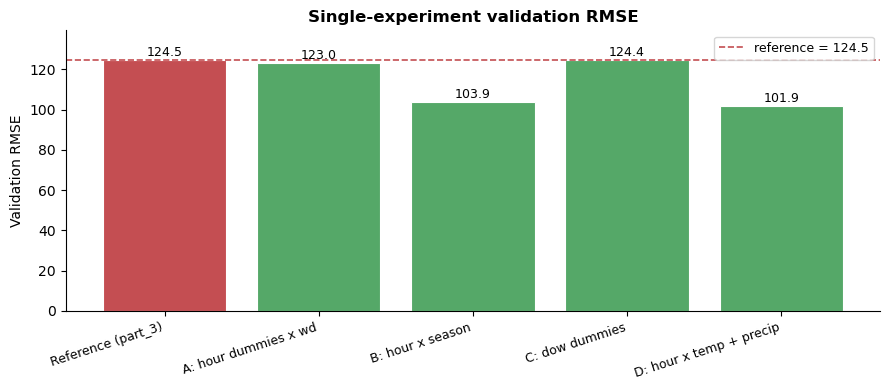

In [18]:
# ── Summary table: single-experiment comparison ───────────────────────────────
results_single = [
    {"Model": "Reference (part_3)",       "Train RMSE": ref_train,       "Val RMSE": ref_val,       "Test RMSE": ref_test,       "Δ Val": 0.0},
    {"Model": res_A["label"],             "Train RMSE": res_A["train"],  "Val RMSE": res_A["val"],  "Test RMSE": res_A["test"],  "Δ Val": res_A["val"]  - ref_val},
    {"Model": res_B["label"],             "Train RMSE": res_B["train"],  "Val RMSE": res_B["val"],  "Test RMSE": res_B["test"],  "Δ Val": res_B["val"]  - ref_val},
    {"Model": res_C["label"],             "Train RMSE": res_C["train"],  "Val RMSE": res_C["val"],  "Test RMSE": res_C["test"],  "Δ Val": res_C["val"]  - ref_val},
    {"Model": res_D["label"],             "Train RMSE": res_D["train"],  "Val RMSE": res_D["val"],  "Test RMSE": res_D["test"],  "Δ Val": res_D["val"]  - ref_val},
]

df_single = pd.DataFrame(results_single).set_index("Model")
df_single["Train MSE"] = df_single["Train RMSE"] ** 2
df_single["Val MSE"]   = df_single["Val RMSE"]   ** 2
df_single["Test MSE"]  = df_single["Test RMSE"]  ** 2

# Display styled table
def highlight_best(s):
    is_best = s == s.min()
    return ["background-color: #c6efce; font-weight: bold" if v else "" for v in is_best]

display_cols = ["Train RMSE", "Val RMSE", "Test RMSE", "Δ Val"]
styled = (df_single[display_cols]
          .style
          .format("{:.2f}")
          .apply(highlight_best, subset=["Val RMSE"])
          .set_caption("Single-experiment comparison (RMSE, lower is better; green = best val)")
          .set_table_styles([{"selector": "caption",
                              "props": [("font-size", "13px"), ("font-weight", "bold"),
                                        ("text-align", "left")]}]))
display(styled)

# Bar chart
labels = df_single.index.tolist()
vals   = df_single["Val RMSE"].tolist()
colors = ["#4C72B0" if v > ref_val else "#55A868" for v in vals]
colors[0] = "#C44E52"  # reference always red

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(len(labels)), vals, color=colors, edgecolor="white", linewidth=0.8)
ax.axhline(ref_val, color="#C44E52", linestyle="--", linewidth=1.2, label=f"reference = {ref_val:.1f}")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.1f}",
            ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=18, ha="right", fontsize=9)
ax.set_ylabel("Validation RMSE")
ax.set_title("Single-experiment validation RMSE", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, max(vals) * 1.12)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 9. Kombineret model — forward selection på udvidet feature-pulje

Tilføj de fire nye feature-grupper til `feature_groups` og kør forward selection på hele puljen. Bemærk at hour_dummies og hour-harmoniske overlapper i hvad de modellerer — forward selection vælger den bedste.


In [19]:
feature_groups_ext = dict(feature_groups)   # copy, already has no lag groups
feature_groups_ext["hour_dummies"]    = hour_dummy_feats
feature_groups_ext["hour_dummies_wd"] = hour_dummy_wd_feats
feature_groups_ext["hour_x_season"]   = hour_x_season_feats
feature_groups_ext["dow_dummies"]     = dow_dummy_feats
feature_groups_ext["hour_x_temp"]     = hour_x_temp_feats
feature_groups_ext["hour_x_precip"]   = hour_x_precip_feats

selected_groups_ext, selected_features_ext, history_ext = forward_select(
    feature_groups_ext, lam=0.0, verbose=True)
print(f"\nSelected groups (extended): {selected_groups_ext}")


(intercept only)           val RMSE = 259.81
hour_dummies_wd            val RMSE = 193.06
temp                       val RMSE = 146.58
hour_x_temp                val RMSE = 120.58
dayofyear_1                val RMSE = 113.04
temp_x_wd                  val RMSE = 107.72
hour_dummies               val RMSE = 102.64
hour_x_season              val RMSE = 99.47
wind_x_wd                  val RMSE = 97.90
temp_sq                    val RMSE = 96.61
precip_x_wd                val RMSE = 95.44
hour_x_precip              val RMSE = 95.02
dow_dummies                val RMSE = 94.71
log_precip                 val RMSE = 94.66
dayofyear_2                val RMSE = 94.62
wind                       val RMSE = 94.59
is_holiday                 val RMSE = 94.56
hour4_8_x_wd               val RMSE = 94.53
wind_sq                    val RMSE = 94.52
is_raining                 val RMSE = 94.51
precip                     val RMSE = 94.50
hour12_x_wd                val RMSE = 94.50
hour_8                   

### λ-scan på den kombinerede model


Best lambda: 0, val RMSE: 94.50
OLS (lam=0)  val RMSE: 94.50


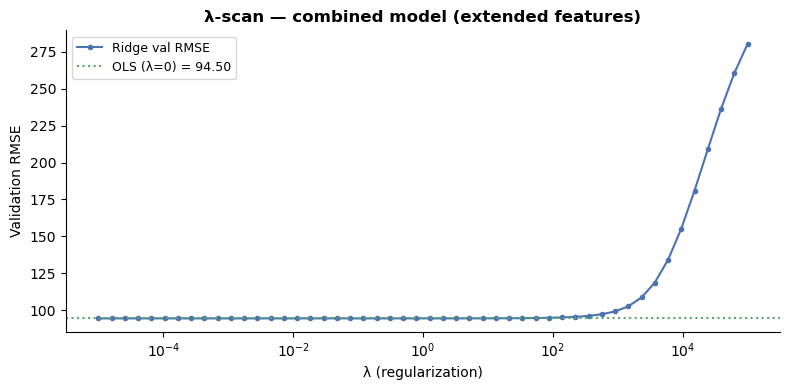

In [20]:
X_tr = build_X(df_training,   selected_features_ext)
X_va = build_X(df_validating, selected_features_ext)
X_te = build_X(df_testing,    selected_features_ext)
X_tr_s, mu_ext, sigma_ext = standardize_train(X_tr)
X_va_s = standardize_apply(X_va, mu_ext, sigma_ext)
X_te_s = standardize_apply(X_te, mu_ext, sigma_ext)

lambdas_ext = np.concatenate([[0.0], np.logspace(-5, 5, 50)])
val_rmses_ext = [calculate_RMSE(X_va_s, ridge_reg(X_tr_s, y_tr, lam), y_va) for lam in lambdas_ext]
best_idx = int(np.argmin(val_rmses_ext))
best_lam = lambdas_ext[best_idx]
ols_rmse = val_rmses_ext[0]
print(f"Best lambda: {best_lam:.6g}, val RMSE: {val_rmses_ext[best_idx]:.2f}")
print(f"OLS (lam=0)  val RMSE: {ols_rmse:.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(lambdas_ext[1:], val_rmses_ext[1:], marker="o", markersize=3,
            color="#4C72B0", label="Ridge val RMSE")
ax.axhline(ols_rmse, color="#55A868", linestyle=":", linewidth=1.5,
           label=f"OLS (λ=0) = {ols_rmse:.2f}")
if best_lam > 0:
    ax.axvline(best_lam, color="#C44E52", linestyle="--", linewidth=1.2,
               label=f"best λ = {best_lam:.4g}")
ax.set_xlabel("λ (regularization)"); ax.set_ylabel("Validation RMSE")
ax.set_title("λ-scan — combined model (extended features)", fontweight="bold")
ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()


### Slutmodel — train, val, test


In [21]:
w_ext = ridge_reg(X_tr_s, y_tr, best_lam)
ext_train = calculate_RMSE(X_tr_s, w_ext, y_tr)
ext_val   = calculate_RMSE(X_va_s, w_ext, y_va)
ext_test  = calculate_RMSE(X_te_s, w_ext, y_te)

results_combined = pd.DataFrame([
    {"Model": "Reference (part_3)",   "λ": 0.0,      "Train RMSE": ref_train,  "Val RMSE": ref_val,  "Test RMSE": ref_test},
    {"Model": "Combined (part_3b)",   "λ": best_lam, "Train RMSE": ext_train,  "Val RMSE": ext_val,  "Test RMSE": ext_test},
]).set_index("Model")
results_combined["Train MSE"] = results_combined["Train RMSE"] ** 2
results_combined["Val MSE"]   = results_combined["Val RMSE"]   ** 2
results_combined["Test MSE"]  = results_combined["Test RMSE"]  ** 2
results_combined["Δ Val"]     = results_combined["Val RMSE"]   - ref_val
results_combined["Δ Test"]    = results_combined["Test RMSE"]  - ref_test

display_cols = ["λ", "Train RMSE", "Val RMSE", "Test RMSE", "Δ Val", "Δ Test"]
display(results_combined[display_cols].style.format({"λ": "{:.4g}", **{c: "{:.2f}" for c in display_cols[1:]}})
        .set_caption("Combined model vs. reference (RMSE, lower is better)"))


,λ,Train RMSE,Val RMSE,Test RMSE,Δ Val,Δ Test
Model,,,,,,
Reference (part_3),0,114.12,124.46,124.18,0.00,0.00
Combined (part_3b),0,85.93,94.50,94.47,-29.96,-29.71


### Residualer efter kombineret model — forsvandt time 8/17-strukturen?


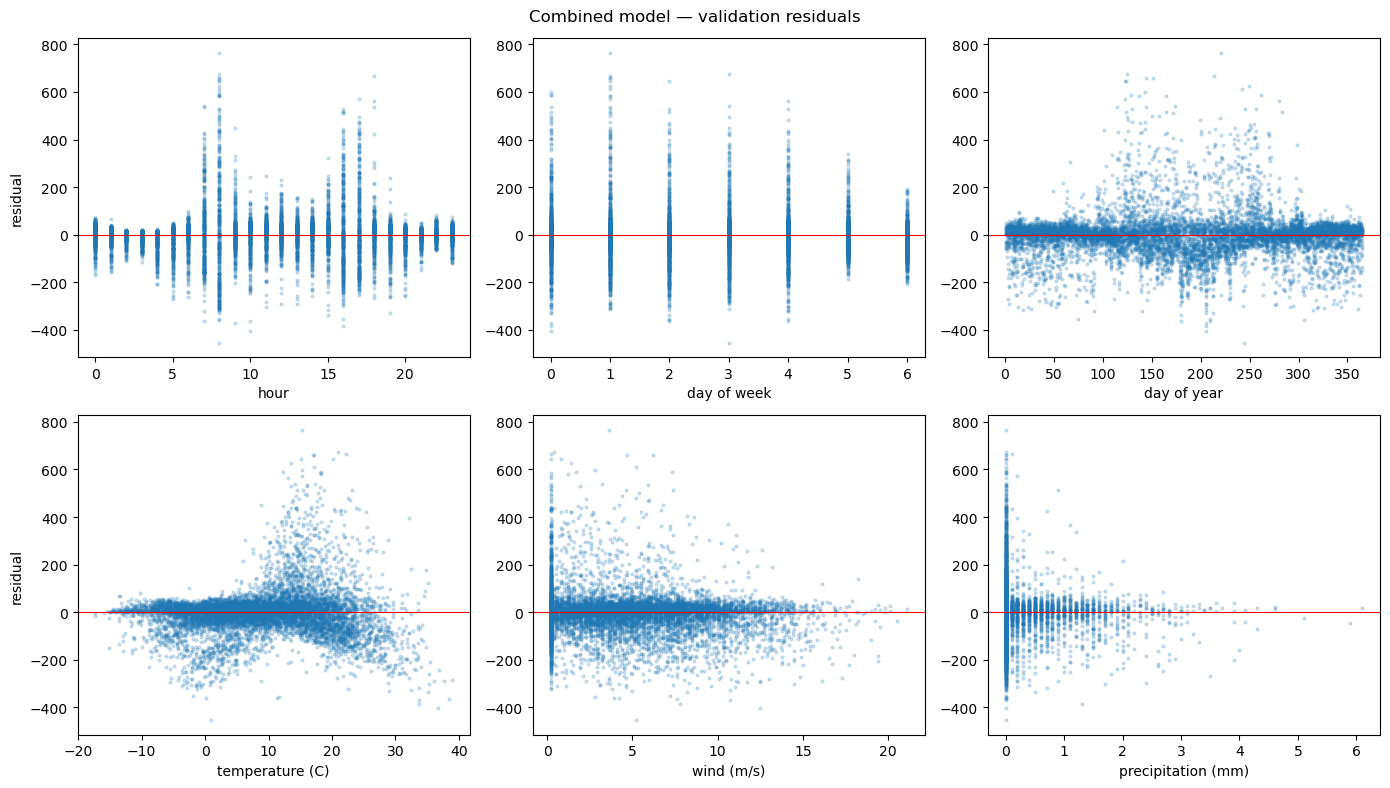

hour 8: ref MAE = 262.03, combined MAE = 194.78
hour 17: ref MAE = 197.62, combined MAE = 133.72


In [22]:
resid_ext_va = y_va - np.maximum((X_va_s @ w_ext).flatten(), 0)
plot_residuals(df_validating, resid_ext_va, "Combined model — validation residuals")

for target_hour in [8, 17]:
    mask = df_validating["datetime"].dt.hour == target_hour
    resid_h_ref = baseline_residuals_va[mask.values]
    resid_h_ext = resid_ext_va[mask.values]
    print(f"hour {target_hour}: ref MAE = {np.mean(np.abs(resid_h_ref)):.2f}, "
          f"combined MAE = {np.mean(np.abs(resid_h_ext)):.2f}")


### Coefficient-fortolkning


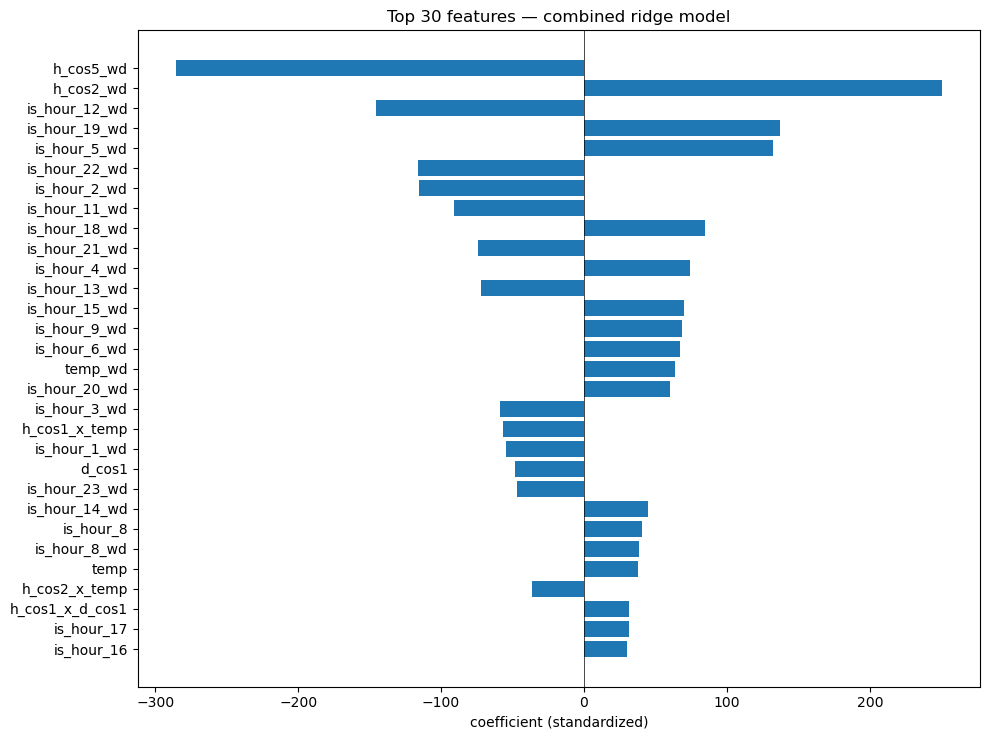

In [23]:
feat_labels_ext = ["intercept"] + selected_features_ext
coefs_ext = w_ext.flatten()
order = np.argsort(np.abs(coefs_ext[1:]))[::-1] + 1  # skip intercept
top_n = min(30, len(order))
order_top = order[:top_n]

plt.figure(figsize=(10, max(4, top_n * 0.25)))
plt.barh(np.array(feat_labels_ext)[order_top][::-1], coefs_ext[order_top][::-1])
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("coefficient (standardized)")
plt.title(f"Top {top_n} features — combined ridge model")
plt.tight_layout(); plt.show()


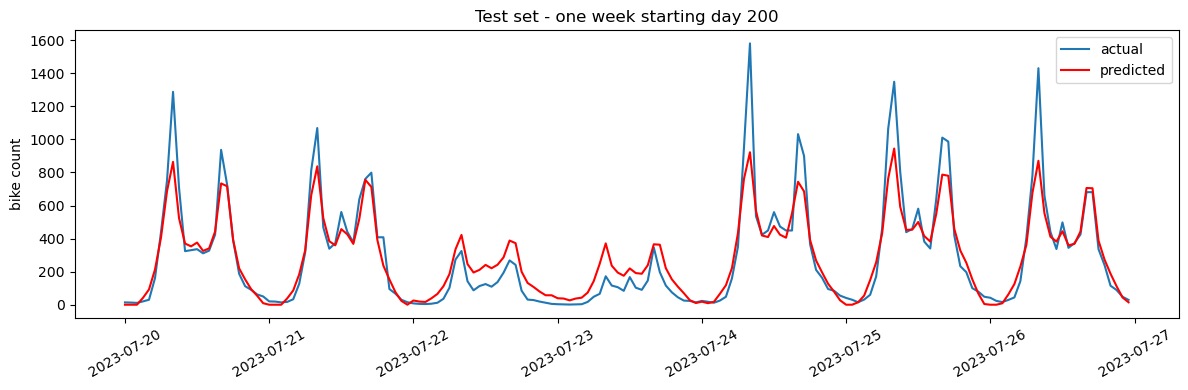

In [24]:
w_final = ridge_reg(X_tr_s, y_tr, best_lam)
y_te_pred = np.maximum((X_te_s @ w_final).flatten(), 0)

day = 200
plt_hours = 24 * 7
plt.figure(figsize=(12, 4))
plt.plot(df_testing["datetime"].values[24*day : 24*day + plt_hours],
         y_te[24*day : 24*day + plt_hours], label="actual")
plt.plot(df_testing["datetime"].values[24*day : 24*day + plt_hours],
         y_te_pred[24*day : 24*day + plt_hours], color="red", label="predicted")
plt.legend(); plt.xticks(rotation=30); plt.ylabel("bike count")
plt.title(f"Test set - one week starting day {day}")
plt.tight_layout()
plt.show()

In [25]:
stations_train = []
stations_test  = []
test_rmses_out = []
val_rmses_out  = []
best_lams_out  = []

def calculate_and_plot_rmse(station1, station2):
    df_tr = add_experimental_features(add_features(
        df_merged[(df_merged["datetime"].dt.year == 2021) &
                  (df_merged["station"] == station1)].copy()
    ))
    df_va = add_experimental_features(add_features(
        df_merged[(df_merged["datetime"].dt.year == 2022) &
                  (df_merged["station"] == station1)].copy()
    ))
    df_te = add_experimental_features(add_features(
        df_merged[(df_merged["datetime"].dt.year == 2023) &
                  (df_merged["station"] == station2)].copy()
    ))

    y_tr_loc = df_tr["bike_count"].values
    y_va_loc = df_va["bike_count"].values
    y_te_loc = df_te["bike_count"].values

    def eval_features_local(feat_names, lam=0.0):
        X_tr_ = build_X(df_tr, feat_names)
        X_va_ = build_X(df_va, feat_names)
        X_tr_s_, mu_, sigma_ = standardize_train(X_tr_)
        X_va_s_ = standardize_apply(X_va_, mu_, sigma_)
        try:
            w_ = ridge_reg(X_tr_s_, y_tr_loc, lam)
        except np.linalg.LinAlgError:
            return np.inf
        return calculate_RMSE(X_va_s_, w_, y_va_loc)

    # Forward selection — no lag groups for cross-station transfer
    groups_to_use = feature_groups_ext   # pure weather+calendar groups, no lags

    selected_groups, selected_features = [], []
    remaining  = list(groups_to_use.keys())
    best_rmse  = eval_features_local([])

    while remaining:
        best_g, best_g_rmse = None, best_rmse
        for g in remaining:
            trial = selected_features + groups_to_use[g]
            rmse  = eval_features_local(trial)
            if rmse < best_g_rmse:
                best_g_rmse, best_g = rmse, g
        if best_g is None:
            break
        selected_groups.append(best_g)
        selected_features += groups_to_use[best_g]
        remaining.remove(best_g)
        best_rmse = best_g_rmse

    print(f"  Selected {len(selected_groups)} groups: {selected_groups}")

    X_tr_ = build_X(df_tr, selected_features)
    X_va_ = build_X(df_va, selected_features)
    X_te_ = build_X(df_te, selected_features)
    X_tr_s_, mu_, sigma_ = standardize_train(X_tr_)
    X_va_s_ = standardize_apply(X_va_, mu_, sigma_)
    X_te_s_ = standardize_apply(X_te_, mu_, sigma_)

    # ── λ-scan using THIS station's data ──────────────────────────────────────
    lambdas_scan = np.concatenate([[0.0], np.logspace(-5, 5, 50)])
    scan_rmses   = [calculate_RMSE(X_va_s_, ridge_reg(X_tr_s_, y_tr_loc, lam), y_va_loc)
                    for lam in lambdas_scan]
    best_idx  = int(np.argmin(scan_rmses))
    best_lam_ = lambdas_scan[best_idx]
    ols_rmse_ = scan_rmses[0]

    w_best    = ridge_reg(X_tr_s_, y_tr_loc, best_lam_)
    test_rmse = calculate_RMSE(X_te_s_, w_best, y_te_loc)
    best_val  = scan_rmses[best_idx]

    label = f"{station1}" if station1 == station2 else f"{station1} → {station2}"
    print(f"  best λ={best_lam_:.4g}  val RMSE={best_val:.2f}  test RMSE={test_rmse:.2f}")

    # ── Plot using LOCAL scan results (fixes the OLS-same-everywhere bug) ─────
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.semilogx(lambdas_scan[1:], scan_rmses[1:], marker="o", markersize=3,
                color="#4C72B0", label="Ridge val RMSE")
    ax.axhline(ols_rmse_, color="#55A868", linestyle=":", linewidth=1.5,
               label=f"OLS (λ=0) = {ols_rmse_:.2f}")
    if best_lam_ > 0:
        ax.axvline(best_lam_, color="#C44E52", linestyle="--", linewidth=1.2,
                   label=f"best λ = {best_lam_:.4g}")
    ax.set_xlabel("λ"); ax.set_ylabel("Validation RMSE")
    ax.set_title(label, fontweight="bold")
    ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.show()

    val_rmses_out.append(best_val)
    best_lams_out.append(best_lam_)
    stations_train.append(station1)
    stations_test.append(station2)
    test_rmses_out.append(test_rmse)

    return {"label": label, "val": best_val, "test": test_rmse, "lam": best_lam_}


  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'wind', 'log_precip', 'wind_sq', 'is_holiday', 'hour4_8_x_wd', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=239.68  test RMSE=238.94


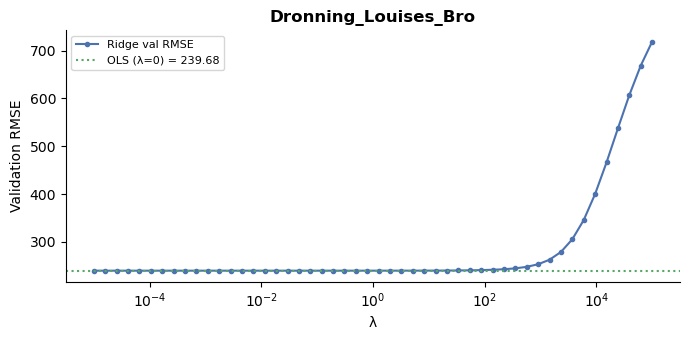

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'wind', 'log_precip', 'wind_sq', 'is_holiday', 'hour4_8_x_wd', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=239.68  test RMSE=333.13


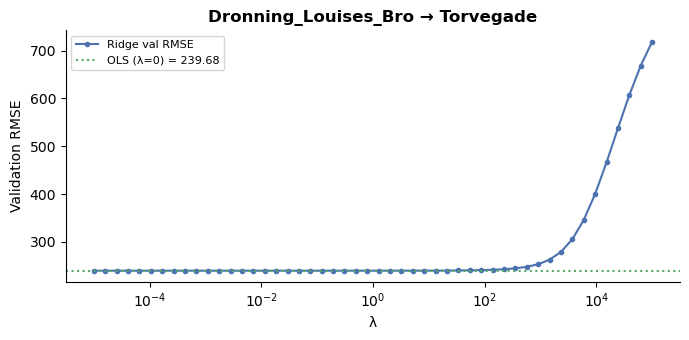

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'wind', 'log_precip', 'wind_sq', 'is_holiday', 'hour4_8_x_wd', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=239.68  test RMSE=225.03


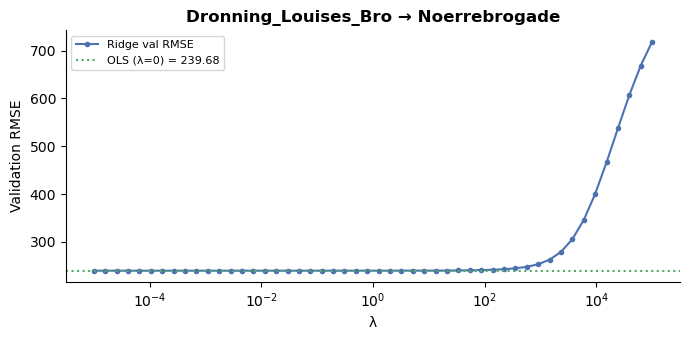

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'wind', 'log_precip', 'wind_sq', 'is_holiday', 'hour4_8_x_wd', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=239.68  test RMSE=407.17


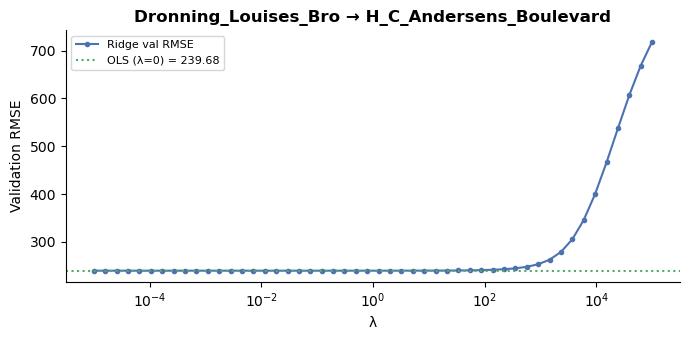

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'wind', 'log_precip', 'wind_sq', 'is_holiday', 'hour4_8_x_wd', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=239.68  test RMSE=448.24


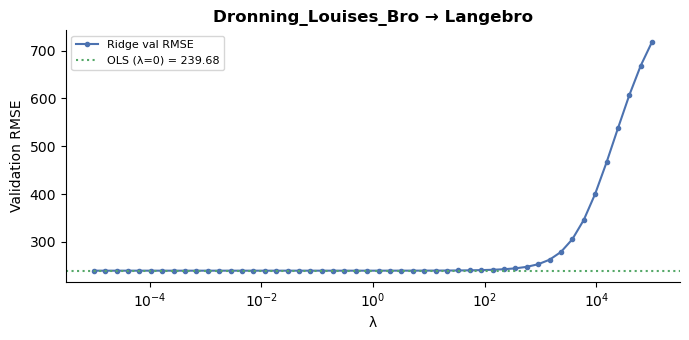

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'wind', 'log_precip', 'wind_sq', 'is_holiday', 'hour4_8_x_wd', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=239.68  test RMSE=490.58


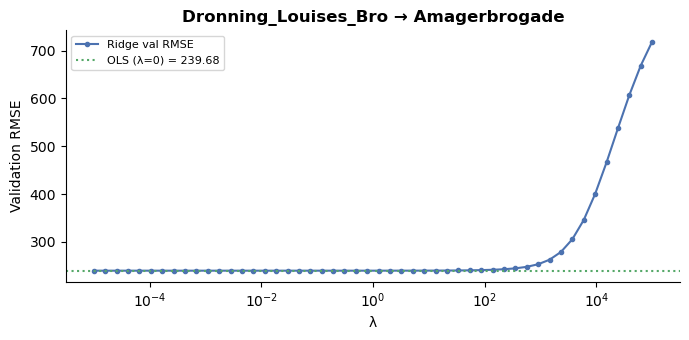

  Selected 24 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'wind_sq', 'is_holiday', 'hour6_x_wd', 'precip', 'is_raining', 'hour_8', 'hour4_8_x_wd', 'hour_6', 'hour24_x_wd', 'hour8_x_wd']
  best λ=0  val RMSE=133.18  test RMSE=447.92


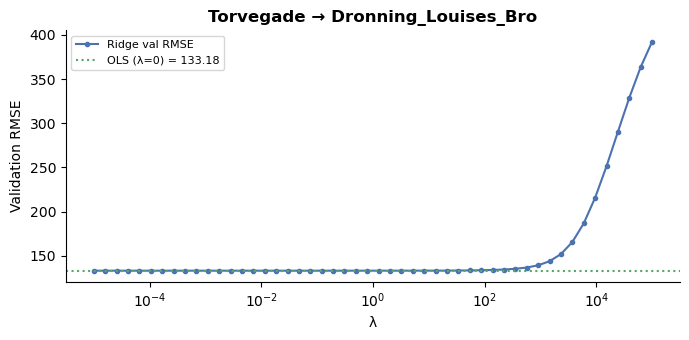

  Selected 24 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'wind_sq', 'is_holiday', 'hour6_x_wd', 'precip', 'is_raining', 'hour_8', 'hour4_8_x_wd', 'hour_6', 'hour24_x_wd', 'hour8_x_wd']
  best λ=0  val RMSE=133.18  test RMSE=133.92


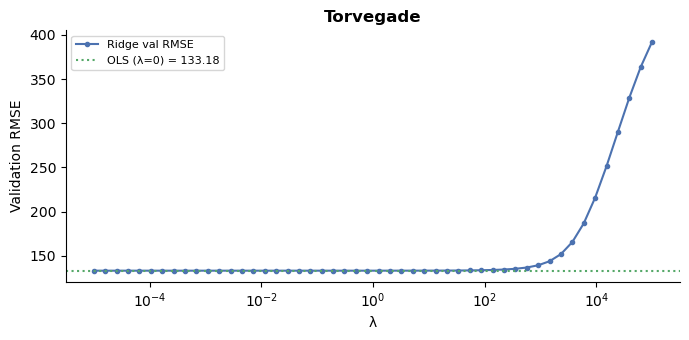

  Selected 24 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'wind_sq', 'is_holiday', 'hour6_x_wd', 'precip', 'is_raining', 'hour_8', 'hour4_8_x_wd', 'hour_6', 'hour24_x_wd', 'hour8_x_wd']
  best λ=0  val RMSE=133.18  test RMSE=276.68


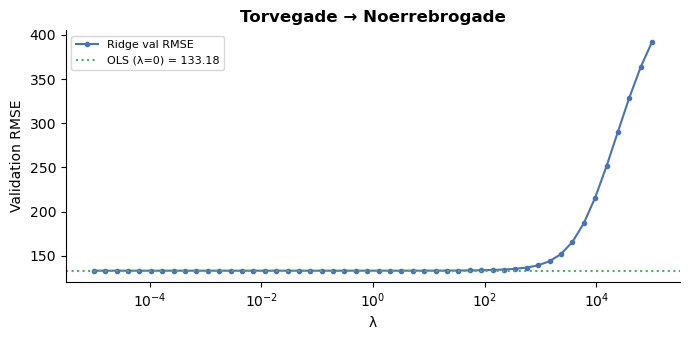

  Selected 24 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'wind_sq', 'is_holiday', 'hour6_x_wd', 'precip', 'is_raining', 'hour_8', 'hour4_8_x_wd', 'hour_6', 'hour24_x_wd', 'hour8_x_wd']
  best λ=0  val RMSE=133.18  test RMSE=122.29


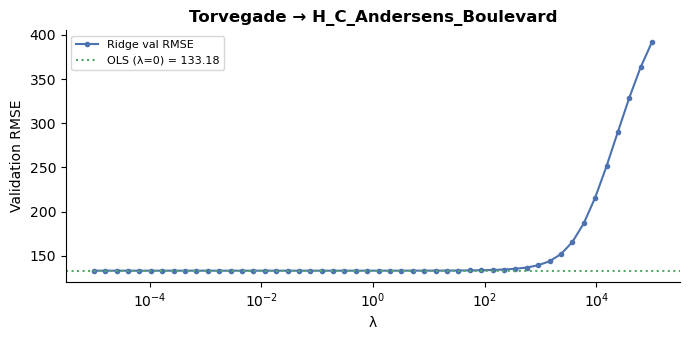

  Selected 24 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'wind_sq', 'is_holiday', 'hour6_x_wd', 'precip', 'is_raining', 'hour_8', 'hour4_8_x_wd', 'hour_6', 'hour24_x_wd', 'hour8_x_wd']
  best λ=0  val RMSE=133.18  test RMSE=142.33


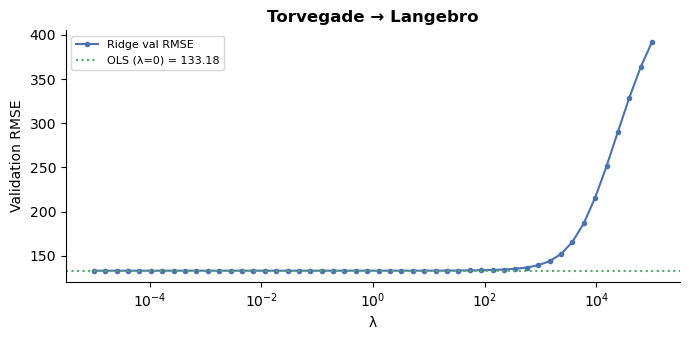

  Selected 24 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'wind_sq', 'is_holiday', 'hour6_x_wd', 'precip', 'is_raining', 'hour_8', 'hour4_8_x_wd', 'hour_6', 'hour24_x_wd', 'hour8_x_wd']
  best λ=0  val RMSE=133.18  test RMSE=172.65


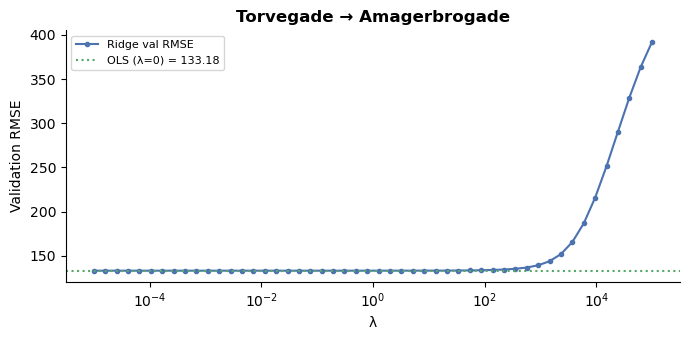

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind', 'wind_sq', 'is_holiday', 'hour4_8_x_wd', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=186.27  test RMSE=315.93


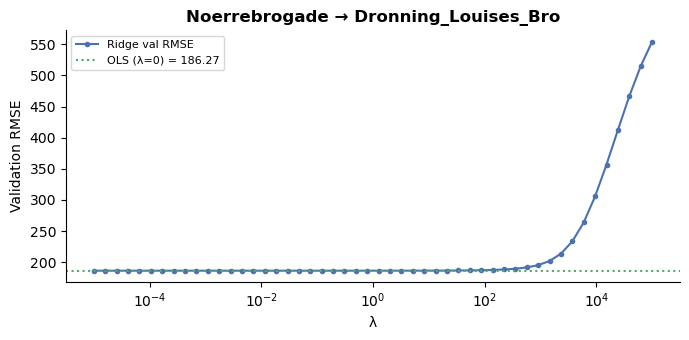

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind', 'wind_sq', 'is_holiday', 'hour4_8_x_wd', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=186.27  test RMSE=195.59


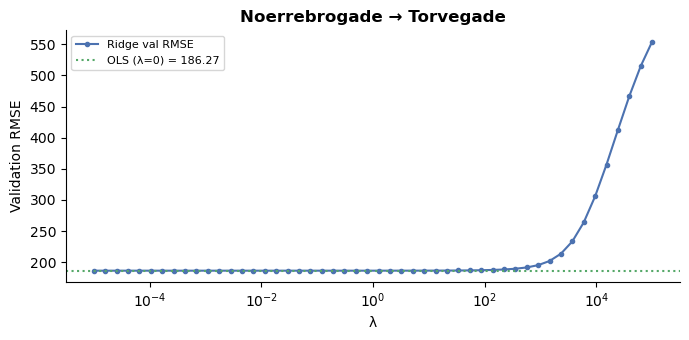

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind', 'wind_sq', 'is_holiday', 'hour4_8_x_wd', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=186.27  test RMSE=189.69


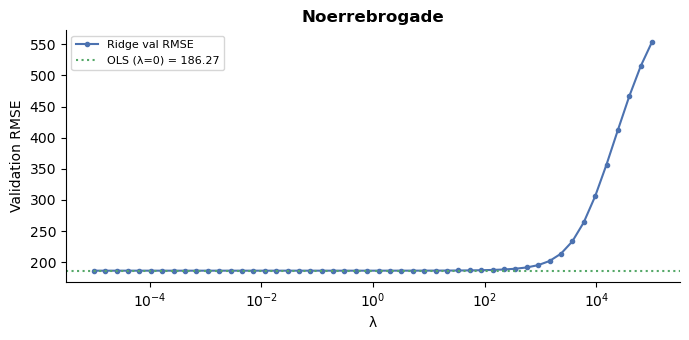

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind', 'wind_sq', 'is_holiday', 'hour4_8_x_wd', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=186.27  test RMSE=254.65


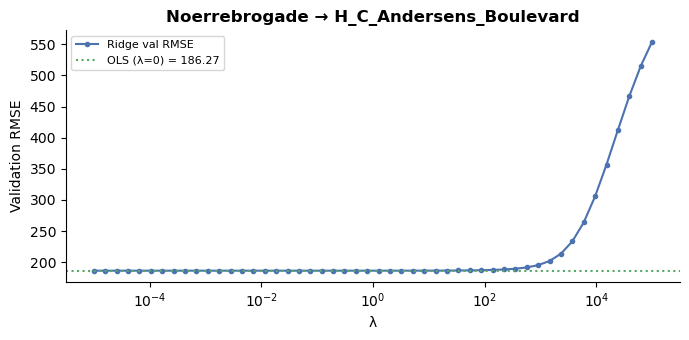

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind', 'wind_sq', 'is_holiday', 'hour4_8_x_wd', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=186.27  test RMSE=292.26


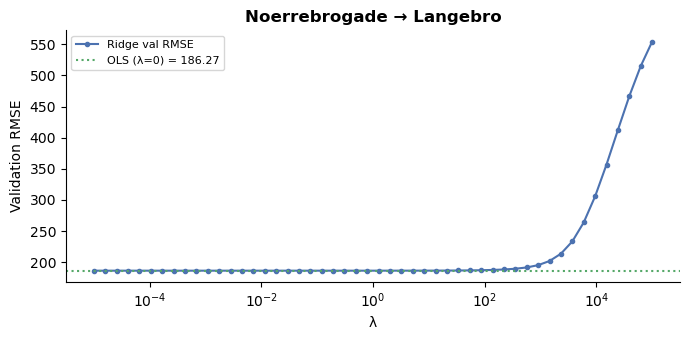

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind', 'wind_sq', 'is_holiday', 'hour4_8_x_wd', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=186.27  test RMSE=332.28


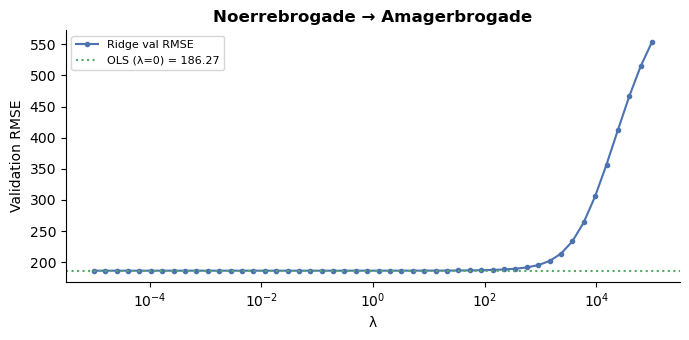

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'hour_dummies', 'temp_x_wd', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'precip', 'is_raining', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=107.95  test RMSE=520.63


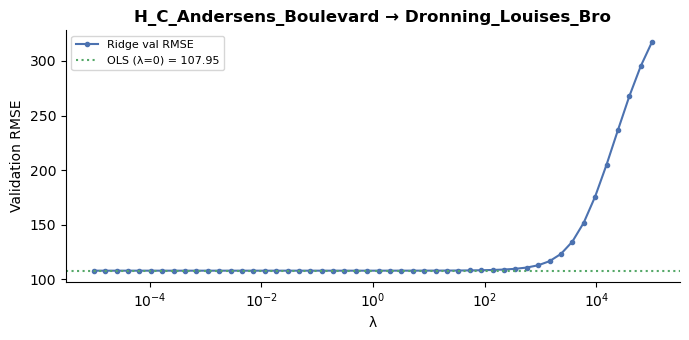

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'hour_dummies', 'temp_x_wd', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'precip', 'is_raining', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=107.95  test RMSE=170.06


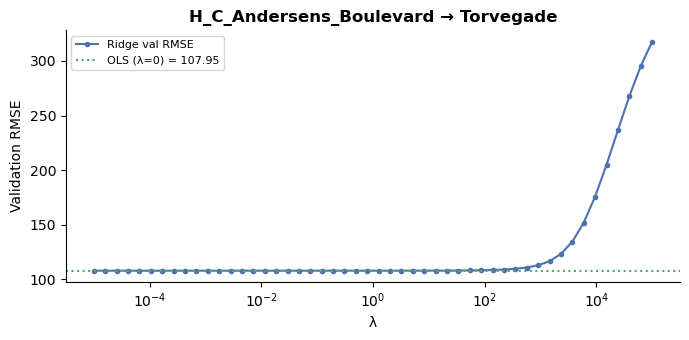

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'hour_dummies', 'temp_x_wd', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'precip', 'is_raining', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=107.95  test RMSE=342.68


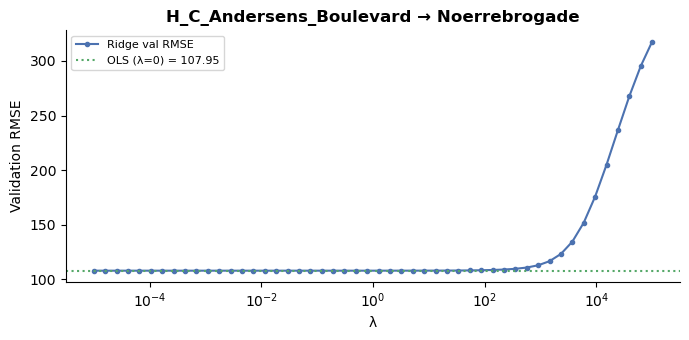

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'hour_dummies', 'temp_x_wd', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'precip', 'is_raining', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=107.95  test RMSE=106.91


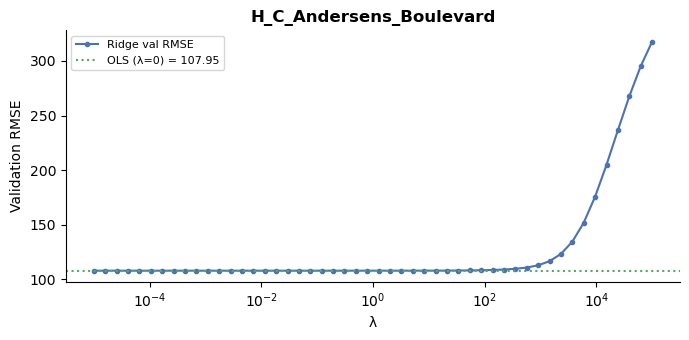

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'hour_dummies', 'temp_x_wd', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'precip', 'is_raining', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=107.95  test RMSE=96.02


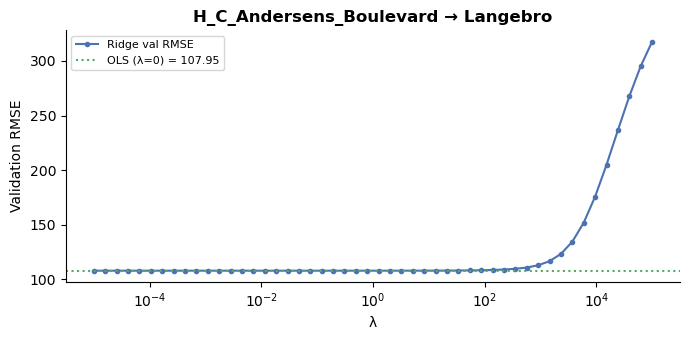

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'hour_dummies', 'temp_x_wd', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'precip', 'is_raining', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=107.95  test RMSE=105.72


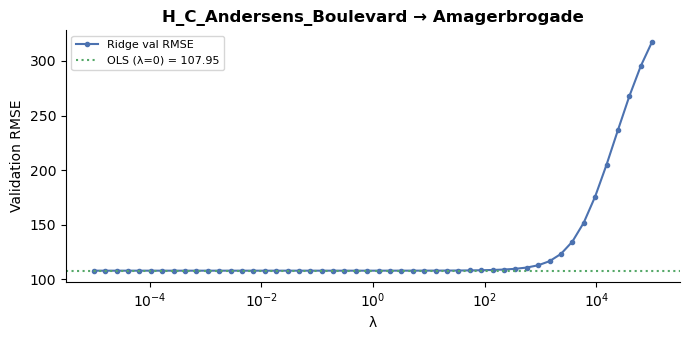

  Selected 22 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'dayofyear_2', 'wind', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=94.50  test RMSE=557.82


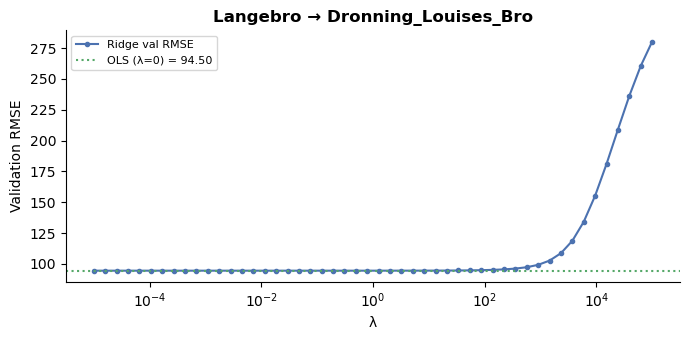

  Selected 22 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'dayofyear_2', 'wind', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=94.50  test RMSE=198.85


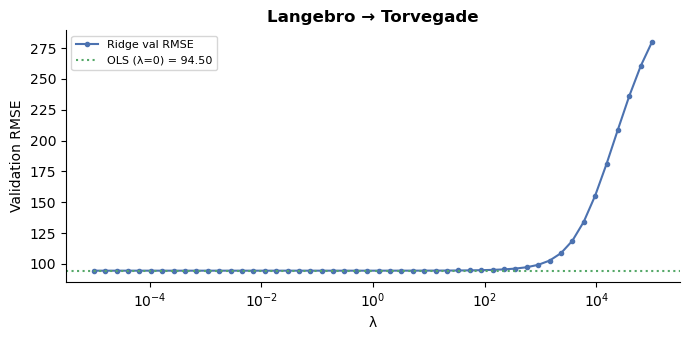

  Selected 22 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'dayofyear_2', 'wind', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=94.50  test RMSE=377.96


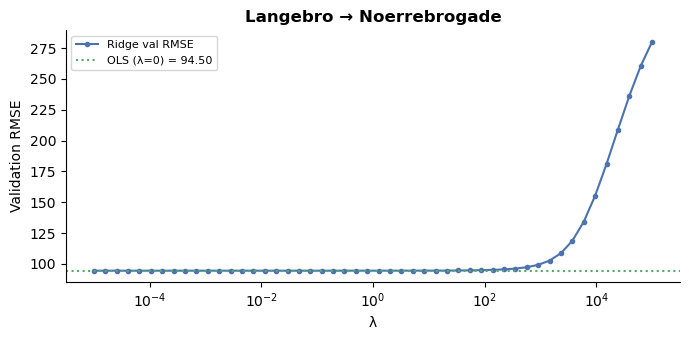

  Selected 22 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'dayofyear_2', 'wind', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=94.50  test RMSE=121.76


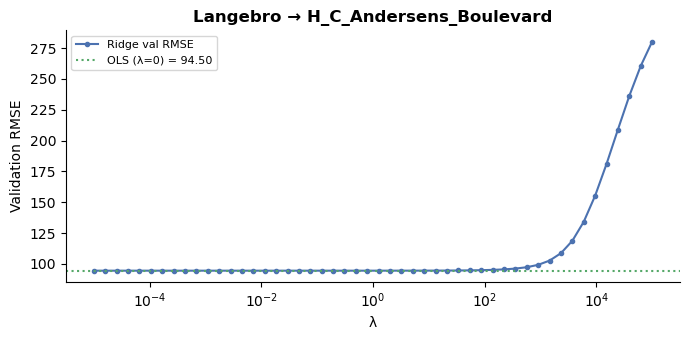

  Selected 22 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'dayofyear_2', 'wind', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=94.50  test RMSE=94.47


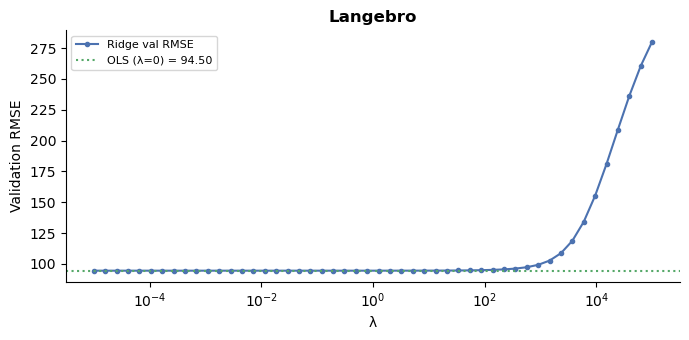

  Selected 22 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'temp_x_wd', 'hour_dummies', 'hour_x_season', 'wind_x_wd', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'dayofyear_2', 'wind', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=94.50  test RMSE=84.32


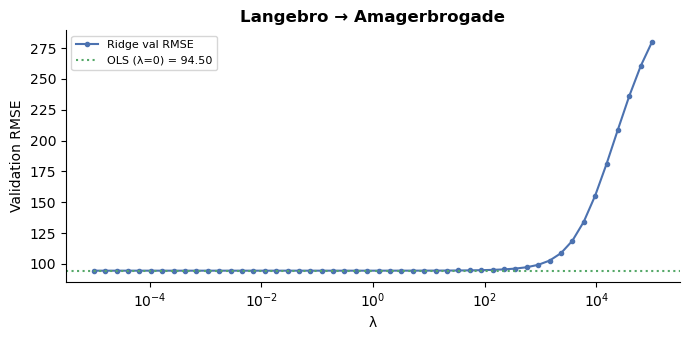

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'hour_dummies', 'temp_x_wd', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=79.55  test RMSE=598.40


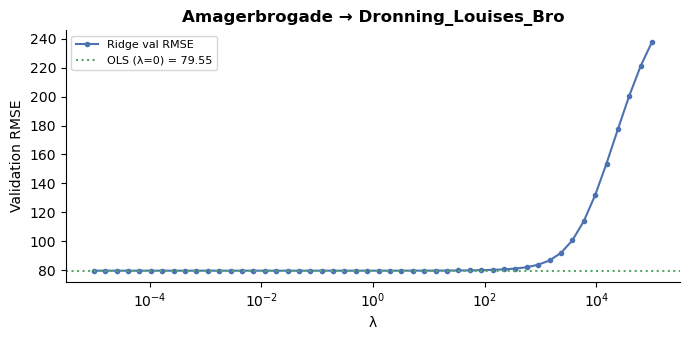

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'hour_dummies', 'temp_x_wd', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=79.55  test RMSE=233.95


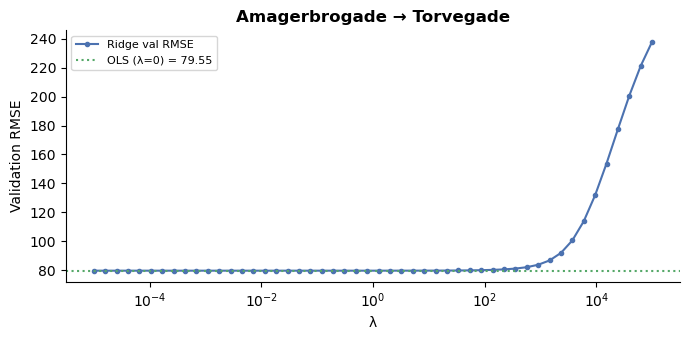

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'hour_dummies', 'temp_x_wd', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=79.55  test RMSE=417.17


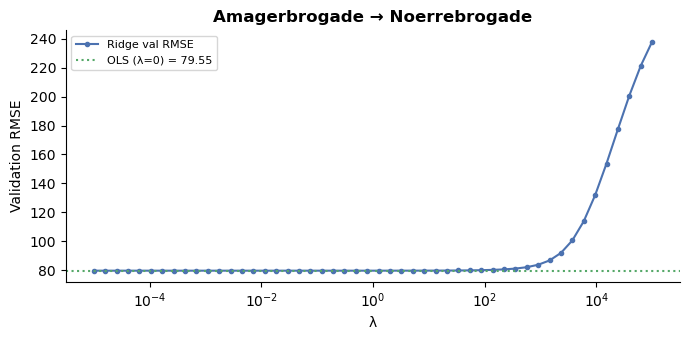

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'hour_dummies', 'temp_x_wd', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=79.55  test RMSE=149.23


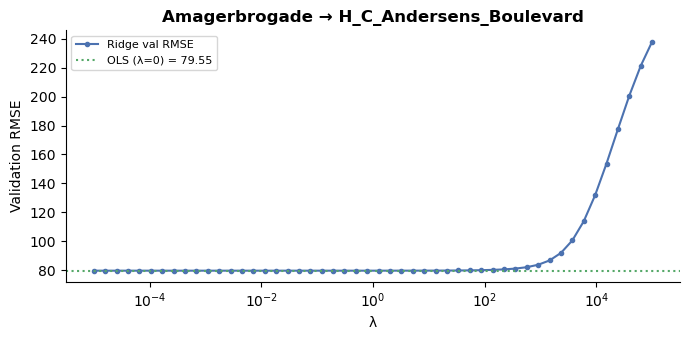

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'hour_dummies', 'temp_x_wd', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=79.55  test RMSE=111.20


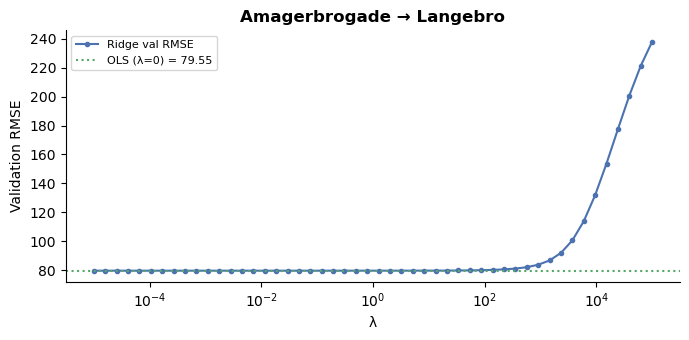

  Selected 21 groups: ['hour_dummies_wd', 'temp', 'hour_x_temp', 'dayofyear_1', 'hour_dummies', 'temp_x_wd', 'hour_x_season', 'wind', 'temp_sq', 'precip_x_wd', 'hour_x_precip', 'dow_dummies', 'log_precip', 'wind_x_wd', 'is_holiday', 'hour4_8_x_wd', 'wind_sq', 'is_raining', 'precip', 'hour12_x_wd', 'hour_8']
  best λ=0  val RMSE=79.55  test RMSE=80.57


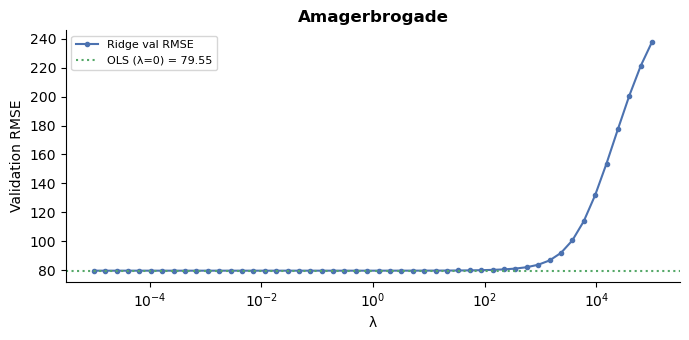

In [26]:
stations = df_stations["station"].unique()
for station1 in stations:
    for station2 in stations:
        calculate_and_plot_rmse(station1, station2)

In [27]:
# ── Cross-station results table ───────────────────────────────────────────────
df_results = pd.DataFrame({
    "Train Station": stations_train,
    "Test Station":  stations_test,
    "Best λ":        best_lams_out,
    "Val RMSE":      val_rmses_out,
    "Test RMSE":     test_rmses_out,
})
df_results["Val MSE"]  = df_results["Val RMSE"]  ** 2
df_results["Test MSE"] = df_results["Test RMSE"] ** 2

# Separate same-station vs transfer tables
same_mask  = df_results["Train Station"] == df_results["Test Station"]
df_same    = df_results[same_mask].set_index("Train Station").drop(columns="Test Station")
df_xfer    = df_results[~same_mask].copy()

print("=== Same-station (train & test on same station, 2021/22 → 2023) ===")
display(df_same[["Best λ","Val RMSE","Test RMSE","Val MSE","Test MSE"]]
        .style.format({"Best λ": "{:.4g}", "Val RMSE": "{:.2f}", "Test RMSE": "{:.2f}",
                       "Val MSE": "{:.0f}", "Test MSE": "{:.0f}"})
        .background_gradient(subset=["Test RMSE"], cmap="RdYlGn_r")
        .set_caption("Per-station model performance (RMSE / MSE on 2023 test set)"))

print("\n=== Cross-station transfer (train on row station, test on column station) ===")
pivot_rmse = df_xfer.pivot(index="Train Station", columns="Test Station", values="Test RMSE")
# include diagonal (same-station test RMSE) for context
for st in df_results["Train Station"].unique():
    row = df_results[(df_results["Train Station"]==st) & (df_results["Test Station"]==st)]
    if not row.empty:
        pivot_rmse.loc[st, st] = row["Test RMSE"].values[0]
pivot_rmse = pivot_rmse.sort_index().sort_index(axis=1)

display(pivot_rmse.style.format("{:.1f}")
        .background_gradient(cmap="RdYlGn_r", axis=None)
        .set_caption("Test RMSE transfer matrix (train→row, test→col). Diagonal = same-station."))


=== Same-station (train & test on same station, 2021/22 → 2023) ===


,Best λ,Val RMSE,Test RMSE,Val MSE,Test MSE
Train Station,,,,,
Dronning_Louises_Bro,0,239.68,238.94,57445,57093
Torvegade,0,133.18,133.92,17736,17935
Noerrebrogade,0,186.27,189.69,34695,35981
H_C_Andersens_Boulevard,0,107.95,106.91,11652,11429
Langebro,0,94.50,94.47,8930,8925
Amagerbrogade,0,79.55,80.57,6328,6492



=== Cross-station transfer (train on row station, test on column station) ===


Test Station,Amagerbrogade,Dronning_Louises_Bro,H_C_Andersens_Boulevard,Langebro,Noerrebrogade,Torvegade
Train Station,,,,,,
Amagerbrogade,80.6,598.4,149.2,111.2,417.2,233.9
Dronning_Louises_Bro,490.6,238.9,407.2,448.2,225.0,333.1
H_C_Andersens_Boulevard,105.7,520.6,106.9,96.0,342.7,170.1
Langebro,84.3,557.8,121.8,94.5,378.0,198.9
Noerrebrogade,332.3,315.9,254.7,292.3,189.7,195.6
Torvegade,172.7,447.9,122.3,142.3,276.7,133.9


## Part 5 — Temporal Features: Lagged Bicycle Counts (Extension 5.B)

This section answers the exam extension 5.B. We investigate whether adding **past traffic counts** as
features improves prediction. The lagged features require real-time observed data at inference time
(not just a weather forecast), so they cannot be used for the cross-station transfer experiment above.

Lag features added:
- `lag_1h`  — bike count 1 hour ago  
- `lag_2h`  — bike count 2 hours ago  
- `lag_24h` — same hour yesterday  
- `lag_168h` — same hour last week (7 days)  


In [39]:
# ── Add lag features to the Langebro splits ───────────────────────────────────
def add_lag_features(df):
    """Add lagged bike-count features; must be called AFTER add_features."""
    df = df.copy()
    df["lag_1h"]    = df["bike_count"].shift(1)
    df["lag_2h"]    = df["bike_count"].shift(2)
    df["lag_24h"]   = df["bike_count"].shift(24)
    df["lag_168h"]  = df["bike_count"].shift(168)   # 7 days
    lag_cols = ["lag_1h", "lag_2h", "lag_24h", "lag_168h"]
    df[lag_cols] = df[lag_cols].fillna(0)
    return df

# Re-split Langebro with lags (df_training/validating/testing already have add_features applied)
df_tr_lag = add_lag_features(df_training)
df_va_lag = add_lag_features(df_validating)
df_te_lag = add_lag_features(df_testing)


### 5.1 — Lag groups definition and forward selection


In [40]:
lag_feature_groups = {
    "lag_1h":       ["lag_1h"],
    "lag_2h":       ["lag_2h"],
    "lag_24h":      ["lag_24h"],
    "lag_168h":     ["lag_168h"],
}

# Extend the best feature set from part_3b with lag candidates
feature_groups_lag = dict(feature_groups_ext)   # weather+calendar only (no lags)
feature_groups_lag.update(lag_feature_groups)

def eval_features_lag(feat_names, lam=0.0):
    X_tr_ = build_X(df_tr_lag, feat_names)
    X_va_ = build_X(df_va_lag, feat_names)
    X_tr_s_, mu_, sigma_ = standardize_train(X_tr_)
    X_va_s_ = standardize_apply(X_va_, mu_, sigma_)
    try:
        w_ = ridge_reg(X_tr_s_, y_tr, lam)
    except np.linalg.LinAlgError:
        return np.inf
    return calculate_RMSE(X_va_s_, w_, y_va)

def forward_select_lag(groups_dict, lam=0.0, verbose=False):
    selected_groups, selected_features = [], []
    remaining = list(groups_dict.keys())
    best_rmse = eval_features_lag([], lam=lam)
    history   = [("(intercept only)", best_rmse)]
    while remaining:
        best_g, best_g_rmse = None, best_rmse
        for g in remaining:
            trial = selected_features + groups_dict[g]
            rmse  = eval_features_lag(trial, lam=lam)
            if rmse < best_g_rmse:
                best_g_rmse, best_g = rmse, g
        if best_g is None:
            break
        selected_groups.append(best_g)
        selected_features += groups_dict[best_g]
        remaining.remove(best_g)
        best_rmse = best_g_rmse
        history.append((best_g, best_rmse))
    if verbose:
        for g, r in history:
            print(f"  {g:25s}  val RMSE = {r:.2f}")
    return selected_groups, selected_features, history

print("Forward selection with lag candidates:")
sel_groups_lag, sel_feats_lag, history_lag = forward_select_lag(
    feature_groups_lag, lam=0.0, verbose=True)
print(f"\nSelected groups: {sel_groups_lag}")


Forward selection with lag candidates:
  (intercept only)           val RMSE = 259.81
  lag_168h                   val RMSE = 132.77
  lag_1h                     val RMSE = 112.35
  hour_dummies               val RMSE = 93.86
  lag_24h                    val RMSE = 88.79
  temp_x_wd                  val RMSE = 84.85
  hour_x_temp                val RMSE = 80.85
  hour_dummies_wd            val RMSE = 78.16
  precip_x_wd                val RMSE = 77.33
  wind                       val RMSE = 76.53
  dow_dummies                val RMSE = 75.87
  lag_2h                     val RMSE = 75.31
  hour_x_precip              val RMSE = 74.98
  temp                       val RMSE = 74.78
  temp_sq                    val RMSE = 74.24
  is_holiday                 val RMSE = 74.14
  dayofyear_2                val RMSE = 74.08
  wind_x_wd                  val RMSE = 74.02
  precip                     val RMSE = 73.97
  is_raining                 val RMSE = 73.95
  wind_sq                    val RMSE 

### 5.2 — λ-scan for the temporal model

Best λ: 33.93   val RMSE: 73.92
OLS (λ=0) val RMSE: 73.94


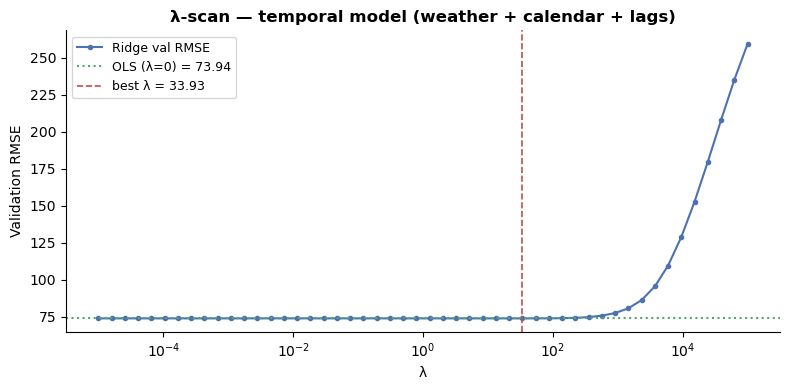

In [41]:
X_tr_l = build_X(df_tr_lag, sel_feats_lag)
X_va_l = build_X(df_va_lag, sel_feats_lag)
X_te_l = build_X(df_te_lag, sel_feats_lag)
X_tr_l_s, mu_lag, sigma_lag = standardize_train(X_tr_l)
X_va_l_s = standardize_apply(X_va_l, mu_lag, sigma_lag)
X_te_l_s = standardize_apply(X_te_l, mu_lag, sigma_lag)

lambdas_lag  = np.concatenate([[0.0], np.logspace(-5, 5, 50)])
rmses_lag    = [calculate_RMSE(X_va_l_s, ridge_reg(X_tr_l_s, y_tr, lam), y_va)
                for lam in lambdas_lag]
best_idx_lag = int(np.argmin(rmses_lag))
best_lam_lag = lambdas_lag[best_idx_lag]
ols_rmse_lag = rmses_lag[0]
print(f"Best λ: {best_lam_lag:.4g}   val RMSE: {rmses_lag[best_idx_lag]:.2f}")
print(f"OLS (λ=0) val RMSE: {ols_rmse_lag:.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(lambdas_lag[1:], rmses_lag[1:], marker="o", markersize=3,
            color="#4C72B0", label="Ridge val RMSE")
ax.axhline(ols_rmse_lag, color="#55A868", linestyle=":", linewidth=1.5,
           label=f"OLS (λ=0) = {ols_rmse_lag:.2f}")
if best_lam_lag > 0:
    ax.axvline(best_lam_lag, color="#C44E52", linestyle="--", linewidth=1.2,
               label=f"best λ = {best_lam_lag:.4g}")
ax.set_xlabel("λ"); ax.set_ylabel("Validation RMSE")
ax.set_title("λ-scan — temporal model (weather + calendar + lags)", fontweight="bold")
ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()


### 5.3 — Results and comparison

In [42]:
w_lag    = ridge_reg(X_tr_l_s, y_tr, best_lam_lag)
lag_tr   = calculate_RMSE(X_tr_l_s, w_lag, y_tr)
lag_val  = calculate_RMSE(X_va_l_s, w_lag, y_va)
lag_test = calculate_RMSE(X_te_l_s, w_lag, y_te)

df_part5 = pd.DataFrame([
    {"Model": "Reference (part_3)",       "λ": 0.0,          "Train RMSE": ref_train, "Val RMSE": ref_val, "Test RMSE": ref_test},
    {"Model": "Combined (part_3b)",        "λ": best_lam,     "Train RMSE": ext_train, "Val RMSE": ext_val, "Test RMSE": ext_test},
    {"Model": "Temporal (part_3b + lags)", "λ": best_lam_lag, "Train RMSE": lag_tr,    "Val RMSE": lag_val, "Test RMSE": lag_test},
]).set_index("Model")
df_part5["Val MSE"]  = df_part5["Val RMSE"]  ** 2
df_part5["Test MSE"] = df_part5["Test RMSE"] ** 2
df_part5["Δ Val"]    = df_part5["Val RMSE"]  - ref_val
df_part5["Δ Test"]   = df_part5["Test RMSE"] - ref_test

display(df_part5[["λ","Train RMSE","Val RMSE","Test RMSE","Val MSE","Test MSE","Δ Val","Δ Test"]]
        .style
        .format({"λ": "{:.4g}", "Train RMSE": "{:.2f}", "Val RMSE": "{:.2f}",
                 "Test RMSE": "{:.2f}", "Val MSE": "{:.0f}", "Test MSE": "{:.0f}",
                 "Δ Val": "{:+.2f}", "Δ Test": "{:+.2f}"})
        .apply(lambda s: ["background-color: #c6efce; font-weight:bold"
                          if v == s.min() else "" for v in s], subset=["Val RMSE"])
        .set_caption("Temporal extension: adding lag features (Langebro station)"))


,λ,Train RMSE,Val RMSE,Test RMSE,Val MSE,Test MSE,Δ Val,Δ Test
Model,,,,,,,,
Reference (part_3),0,114.12,124.46,124.18,15491,15422,+0.00,+0.00
Combined (part_3b),0,85.93,94.50,94.47,8930,8925,-29.96,-29.71
Temporal (part_3b + lags),33.93,70.16,73.92,74.94,5465,5615,-50.54,-49.25


### 5.4 — Test-set prediction: weather-only vs. temporal model

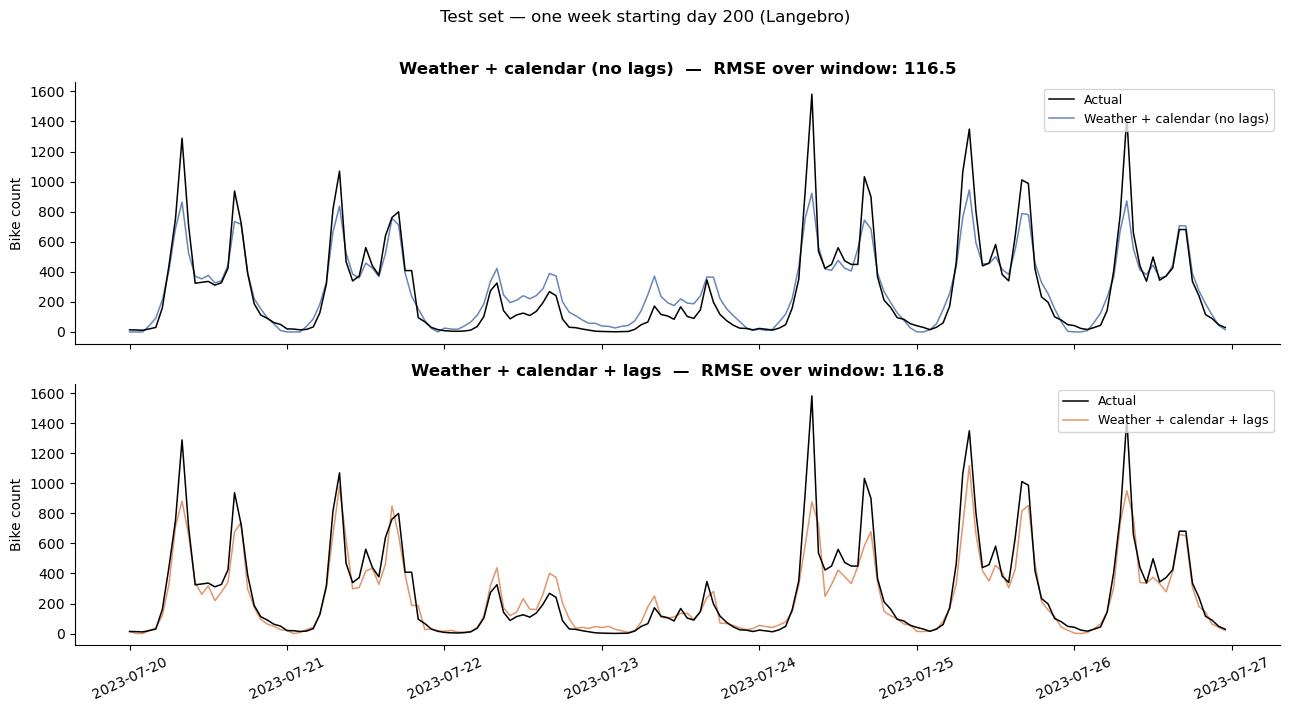

In [37]:
w_no_lag   = ridge_reg(X_tr_s, y_tr, best_lam)
y_pred_nol = np.maximum((X_te_s   @ w_no_lag).flatten(), 0)
y_pred_lag = np.maximum((X_te_l_s @ w_lag).flatten(),    0)

day      = 200
n_hours  = 24 * 7
sl       = slice(24 * day, 24 * day + n_hours)
t_axis   = df_testing["datetime"].values[sl]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

for ax, pred, label, color in zip(
        axes,
        [y_pred_nol[sl], y_pred_lag[sl]],
        ["Weather + calendar (no lags)", "Weather + calendar + lags"],
        ["#4C72B0", "#DD8452"]):
    ax.plot(t_axis, y_te[sl], color="black", linewidth=1.1, label="Actual", zorder=3)
    ax.plot(t_axis, pred,     color=color,  linewidth=1.1, label=label, alpha=0.85)
    rmse_w = np.sqrt(np.mean((pred - y_te[sl])**2))
    ax.set_ylabel("Bike count")
    ax.legend(fontsize=9, loc="upper right")
    ax.set_title(f"{label}  —  RMSE over window: {rmse_w:.1f}", fontweight="bold")
    ax.spines[["top","right"]].set_visible(False)

plt.xticks(rotation=25)
fig.suptitle(f"Test set — one week starting day {day} (Langebro)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


### 5.5 — Discussion: practical implications of the temporal model

The temporal model uses lagged bike counts as features. This means:

- **At prediction time, recent observed counts must be available** (from live sensor data).  
  The weather-only model needs only a weather forecast.
- Lag features capture short-term autocorrelation that weather alone cannot explain —  
  e.g. an unusually busy or quiet hour propagates into the next hour.
- `lag_24h` and `lag_168h` can encode events or anomalies that repeat on a daily/weekly cycle.
- **Practical limitation:** if the sensor goes down (≈2% of data is missing), lag features  
  become unavailable or must be imputed, degrading accuracy.
- For **real-time traffic management** the temporal model is preferable.  
  For **long-horizon planning** (e.g. next-week forecasts from a weather model), the weather-only  
  model is more practical since future lag values are not observed.
